### dataset 65
#### Johanna Tilešová - 50%
#### Adam Pečenka - 50%

Nacitanie a prichystanie dat podla fazy 1

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
import matplotlib as mpl
import category_encoders as ce
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PowerTransformer, QuantileTransformer


In [68]:
mpl.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_theme(palette="vanimo")

In [69]:
df_observation = pd.read_csv('datasets/observation.csv',sep='\t')
df_station = pd.read_csv('datasets/station.csv',sep='\t')

RANDOM_STATE = 123

In [70]:
df_observation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12047 entries, 0 to 12046
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SpO₂                   12047 non-null  float64
 1   HR                     12047 non-null  float64
 2   PI                     12047 non-null  float64
 3   RR                     12047 non-null  float64
 4   EtCO₂                  12047 non-null  float64
 5   FiO₂                   12047 non-null  float64
 6   PRV                    12047 non-null  float64
 7   BP                     12047 non-null  float64
 8   Skin Temperature       12047 non-null  float64
 9   Motion/Activity index  12047 non-null  float64
 10  PVI                    12047 non-null  float64
 11  Hb level               12047 non-null  float64
 12  SV                     12047 non-null  float64
 13  CO                     12047 non-null  float64
 14  Blood Flow Index       12047 non-null  float64
 15  PP

In [71]:
df_station.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 831 entries, 0 to 830
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   code       829 non-null    object 
 1   QoS        831 non-null    object 
 2   longitude  831 non-null    float64
 3   revision   831 non-null    object 
 4   location   831 non-null    object 
 5   latitude   831 non-null    float64
dtypes: float64(2), object(4)
memory usage: 39.1+ KB


In [72]:
dups = (
    df_station[df_station.duplicated(subset=['latitude', 'longitude'], keep=False)]
    .sort_values(['latitude', 'longitude'])
)
dups

,code,QoS,longitude,revision,location,latitude
84,AU,good,145.13643,25 Oct 2016,Australia/Melbourne,-38.16604
102,AU,good,145.13643,"06/14/2024, 00:00:00",Australia/Melbourne,-38.16604
669,AU,good,145.13643,2020/12/03,Australia/Melbourne,-38.16604
406,AR,good,-58.70072,01 Dec 2022,America/Argentina/Buenos_Aires,-34.74785
489,AR,good,-58.70072,"09/04/2019, 00:00:00",America/Argentina/Buenos_Aires,-34.74785
...,...,...,...,...,...,...
151,RU,acceptable,34.34691,2023/08/18,Europe/Moscow,61.78491
337,RU,good,34.34691,"10/18/2019, 00:00:00",Europe/Moscow,61.78491
287,FI,excellent,24.14662,"11/13/2024, 00:00:00",Europe/Helsinki,65.84811
630,FI,excellent,24.14662,2018-11-10,Europe/Helsinki,65.84811


- vidime ze stations maju duplicitne zaznamy pre suradnice, to by nam vyrobilo vela nechcenych dat pri spajani datasetov
- v datasete upraceme datumy na rovnaky format, aby sme ho mohli zoradit podla toho datumu, a vyberieme suradnicovy zaznam s najaktualnejsim zaznamom

In [73]:
df_station['revision'] = pd.to_datetime(
    df_station['revision'],
    format='mixed',
    errors='coerce'
)
df_station = df_station.sort_values('revision', ascending=False)
df_station = df_station.drop_duplicates(subset=['latitude', 'longitude'], keep='first')

df_station.shape

(558, 6)

In [74]:
df = df_observation.merge(df_station, how='inner', on=['latitude', 'longitude'], validate='many_to_one')
df.shape

(12047, 27)

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12047 entries, 0 to 12046
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   SpO₂                   12047 non-null  float64       
 1   HR                     12047 non-null  float64       
 2   PI                     12047 non-null  float64       
 3   RR                     12047 non-null  float64       
 4   EtCO₂                  12047 non-null  float64       
 5   FiO₂                   12047 non-null  float64       
 6   PRV                    12047 non-null  float64       
 7   BP                     12047 non-null  float64       
 8   Skin Temperature       12047 non-null  float64       
 9   Motion/Activity index  12047 non-null  float64       
 10  PVI                    12047 non-null  float64       
 11  Hb level               12047 non-null  float64       
 12  SV                     12047 non-null  float64       
 13  C

In [76]:
df.rename(columns={'SpO₂': 'SpO2', 'EtCO₂': 'EtCO2', 'FiO₂': 'FiO2', 'O₂ extraction ratio': 'O2 extraction ratio'}, inplace=True)

In [77]:
def getOutliers(a):
    lower = a.quantile(0.25) - 1.5 * stats.iqr(a)
    upper = a.quantile(0.75) + 1.5 * stats.iqr(a)

    return (a > upper) | (a < lower)

def cleanOutliers(df):

    for col in df.columns:
        mask = getOutliers(df[col])
        below = df[col].quantile(0.05)
        above = df[col].quantile(0.95)

        df.loc[mask, col] = np.where(
            df.loc[mask, col] < below,
            below,
            above
        )

    return df

def histogramiada(df, bins=30):
    numeric_cols = df.select_dtypes(include=np.number).columns
    n_cols = len(numeric_cols)

    if n_cols == 0:
        print("[!] No numeric columns to plot.")
        return

    per_page = 9
    n_pages = int(np.ceil(n_cols / per_page))

    for page in range(n_pages):
        start = page * per_page
        end = start + per_page
        cols_subset = numeric_cols[start:end]

        fig, axes = plt.subplots(3, 3, figsize=(12, 10))
        axes = axes.flatten()

        for i, col in enumerate(cols_subset):
            sns.histplot(df[col], bins=bins, kde=True, ax=axes[i],
                         color=sns.color_palette("tab10")[i % 10])
            axes[i].set_title(col, fontsize=11)
            axes[i].set_xlabel("")
            axes[i].set_ylabel("")

        # hide unused subplots if fewer than 9
        for j in range(len(cols_subset), len(axes)):
            axes[j].set_visible(False)

        plt.suptitle(f"Numeric Columns {start + 1}–{min(end, n_cols)}", fontsize=13)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()


# 2.1 Realizácia predspracovania dát

##### (A-1b) Dáta si rozdeľte na trénovaciu a testovaciu množinu podľa vami preddefinovaného pomeru. Ďalej pracujte len s trénovacím datasetom

- data si rozdelime v pomere 80/20 a dalej pracujeme uz len s trenovacou mnozinou

In [78]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)
print(df_train.shape,df_test.shape)

(9637, 27) (2410, 27)


##### (B-1b) Transformujte dáta na vhodný formát pre strojové učenie t.j. jedno pozorovanie musí byť opísané jedným riadkom a každý atribút musí byť v numerickom formáte. Iteratívne integrujte aj kroky v predspracovaní dát z prvej fázy ako celok.

- v prvom rade doplnime chybajuce hodnoty -> kody krajiny
- z fazy 1 vieme ze chybajuce kody pochadzaju z afriky

In [79]:
country_code = df_train[df_train['location'].str.split("/").str[0] == 'Africa']['code'].mode().iat[0]
df_train['code'] = df_train['code'].fillna(country_code)

- zistime ake kategoricke stlpce mame v datasete

In [80]:
catCols = df_train.select_dtypes(include=['object']).columns.tolist()
catCols

['code', 'QoS', 'location']

- zistime kolko unikatnych a akych hodnot maju nase kategoricke stlpce

In [81]:
print(f'code: {df_train['code'].nunique()}')
print(f'QoS: {df_train['QoS'].nunique()}')
print(f'QoS: {df_train['QoS'].unique()}')
print(f'location: {df_train['location'].nunique()}')

code: 112
QoS: 4
QoS: ['good' 'acceptable' 'excellent' 'maintenance']
location: 147


- pre QoS pouzijeme OrdinalEncoder lebo ide o hodnoty ktore maju prirodzenu postupnost
- pre code a location pouzijeme Nominalny encoder (napr. CatBoost)

In [82]:
def encodeCategorical(df):
    ordinalEncoder = ce.OrdinalEncoder(cols = ['QoS'])
    hashEncoder = ce.CatBoostEncoder(cols = ['code', 'location'])

    df['QoS'] = ordinalEncoder.fit_transform(df[['QoS']])
    df[['code', 'location']] = hashEncoder.fit_transform(df[['code', 'location']], df['oximetry'])
    return df

df_train = encodeCategorical(df_train)
df_train.describe()

,SpO2,HR,PI,RR,EtCO2,FiO2,PRV,BP,Skin Temperature,Motion/Activity index,PVI,Hb level,SV,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O2 extraction ratio,SNR,oximetry,latitude,longitude,code,QoS,revision,location
count,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637,9637.000000
mean,97.266828,80.724023,9.833733,16.131086,40.489667,56.497242,103.936585,104.514186,35.712037,10.689450,14.351089,14.886433,82.720542,4.162654,52.072476,57.255940,49.014770,53.473354,0.249392,30.009485,0.592093,27.908817,14.472421,0.598143,1.972294,2021-12-02 13:37:12.022413568,0.597300
min,95.048839,60.000000,0.200000,12.000000,35.000000,21.000000,20.000000,91.487986,33.000000,0.476937,10.299163,12.000000,60.000000,4.000000,3.704324,0.000000,0.000000,0.000000,0.200013,20.000636,0.000000,-54.800000,-123.026210,0.059209,1.000000,2015-09-25 00:00:00,0.059209
25%,96.868691,77.293640,8.020234,15.065666,39.141739,50.402237,89.606594,102.003723,35.314486,8.399857,13.124307,14.333497,79.609906,4.052919,43.615743,48.905422,39.981792,44.057535,0.224207,24.989553,0.000000,13.518250,-45.947220,0.567662,1.000000,2019-12-24 00:00:00,0.563893
50%,97.263699,80.702462,9.839743,15.923723,40.714695,56.323702,103.912537,104.510865,35.709300,10.785609,14.326844,14.876540,82.704905,4.099731,52.230958,57.180632,48.931115,53.630725,0.248969,30.116379,1.000000,34.850000,13.442750,0.596601,2.000000,2022-05-03 00:00:00,0.597960
75%,97.667609,84.138226,11.630786,17.284944,41.860276,62.567040,118.135464,107.009333,36.112258,13.261134,15.547087,15.447673,85.834800,4.190926,60.565584,65.680914,58.099255,62.882601,0.274399,35.019939,1.000000,45.780710,72.545660,0.624822,3.000000,2024-05-08 00:00:00,0.627951
max,100.000000,100.000000,20.000000,20.000000,45.000000,100.000000,182.355681,120.000000,37.964560,18.678268,20.000000,18.000000,100.000000,8.000000,100.000000,100.000000,97.568080,100.000000,0.299999,40.000000,1.000000,68.798330,171.253640,0.968623,4.000000,2025-09-11 00:00:00,0.968623
std,0.596007,5.158161,2.694727,1.343025,1.731612,9.105016,21.727808,3.706069,0.601741,3.124738,1.508837,0.818036,4.599266,0.206841,12.498617,12.553993,13.373956,13.939431,0.028873,5.775541,0.491471,23.464393,71.205850,0.088204,0.983551,NaN,0.097310


- odstranime outliers tak ze ich hodnoty zmenime na krajne hodnoty 5% 95%

In [83]:
df_train = cleanOutliers(df_train)

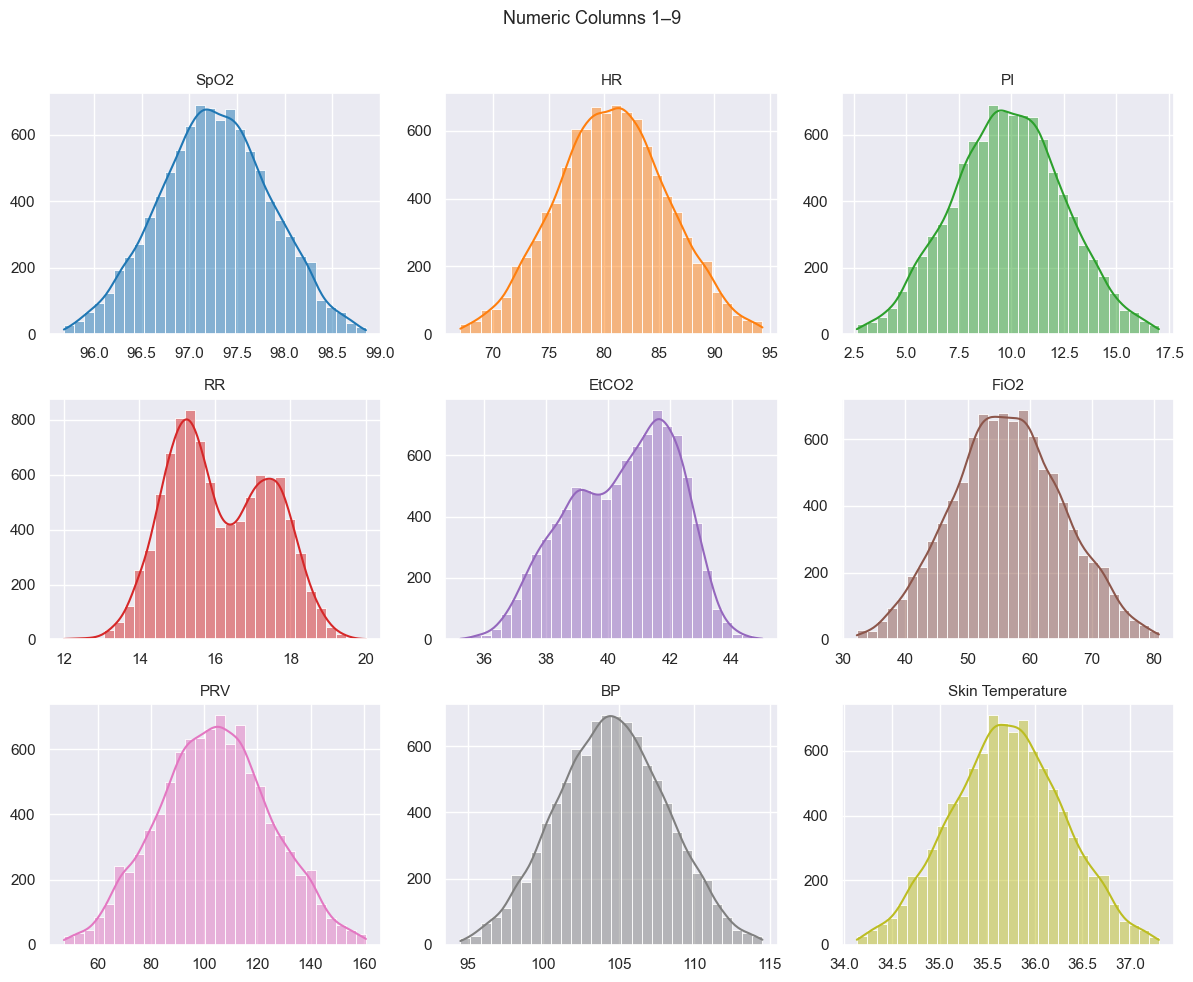

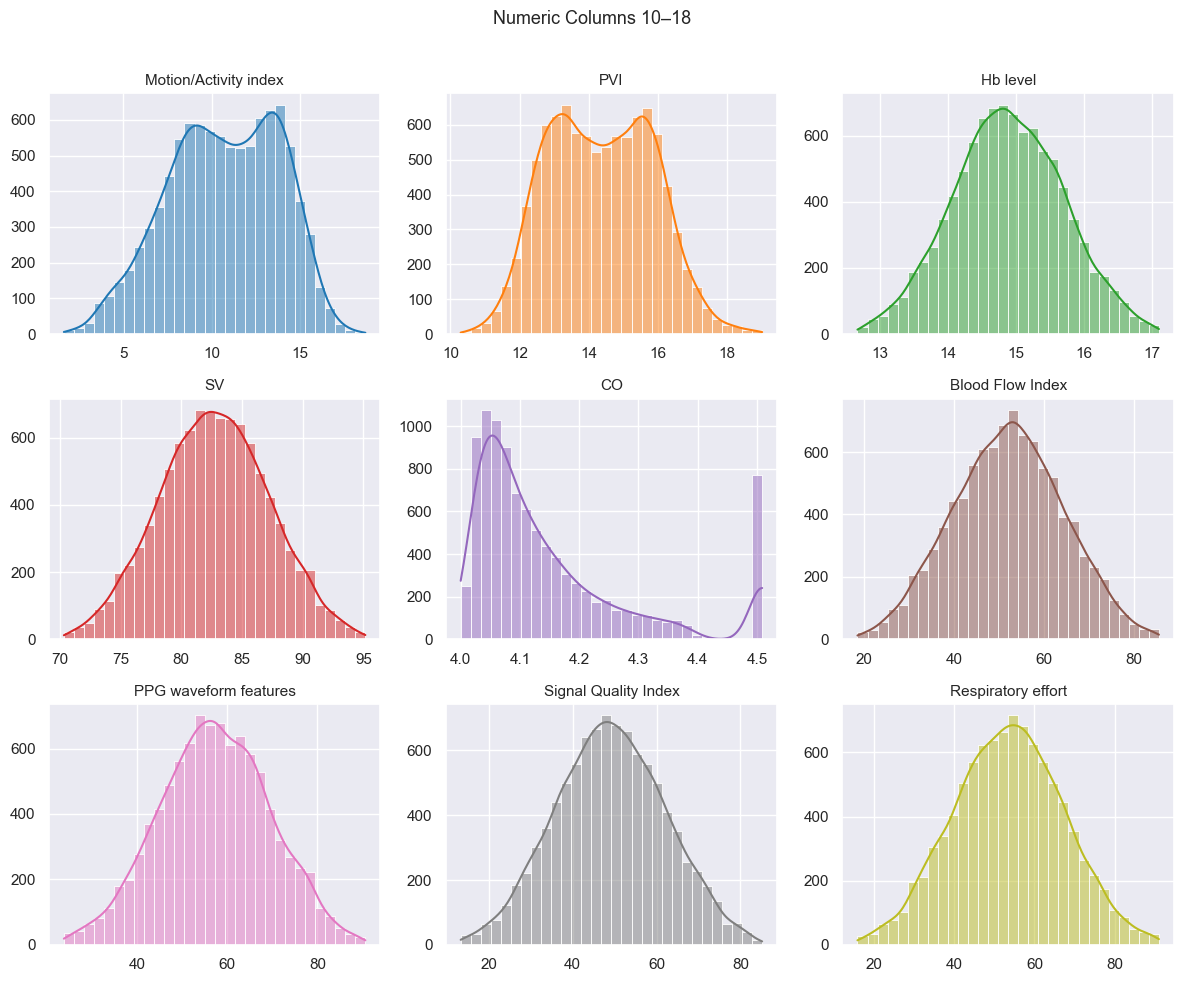

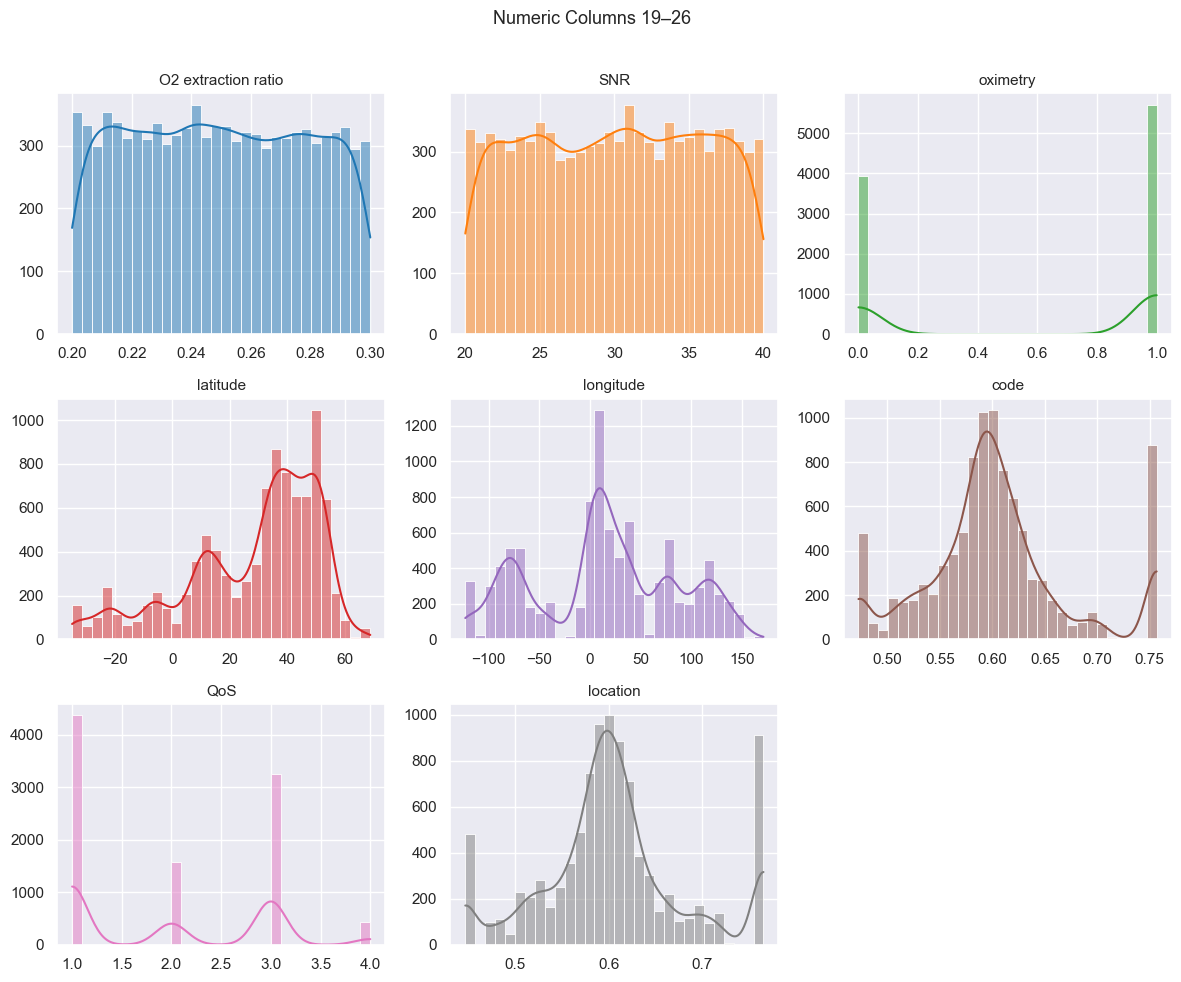

In [84]:
# bezi dlho
histogramiada(df_train)

##### (C-1b) Transformujte atribúty dát pre strojové učenie podľa dostupných techník minimálne: scaling (2 techniky), transformers (2 techniky) a ďalšie. Cieľom je aby ste testovali efekty a vhodne kombinovali v dátovom pipeline (od časti 2.3 a v 3. fáze).

- odstranime stlpec revision, lebo je formatu datetime, co sa blbo zakoduje, nieje pre nas potrebny a robil by problem dalej kvoli svojmu datovemu typu

In [85]:
df_train = df_train.drop(columns=['revision'])

- prichystame priecinok pre nase pickles :3

In [86]:
os.makedirs("pickles", exist_ok=True)

- Vyskusame a pozrieme sa na to co s nasimi datami spravia transformeri a scaleri

- Power Trasnformer

In [87]:
def powerTransform(df):
    pt = PowerTransformer(method='yeo-johnson')
    res =  pt.fit_transform(df)
    return pd.DataFrame(res, columns=df_train.columns, index=df_train.index)

               SpO2            HR            PI            RR         EtCO2          FiO2           PRV            BP  Skin Temperature  Motion/Activity index           PVI  \
count  9.637000e+03  9.637000e+03  9.637000e+03  9.637000e+03  9.637000e+03  9.637000e+03  9.637000e+03  9.637000e+03      9.637000e+03           9.637000e+03  9.637000e+03   
mean   4.138135e-17  2.422422e-15 -3.859802e-16  3.963762e-15  1.961237e-16 -6.683688e-16  4.394350e-16  4.364857e-16      7.122385e-16           1.684746e-16 -1.374340e-15   
std    1.000052e+00  1.000052e+00  1.000052e+00  1.000052e+00  1.000052e+00  1.000052e+00  1.000052e+00  1.000052e+00      1.000052e+00           1.000052e+00  1.000052e+00   
min   -2.701475e+00 -2.745884e+00 -2.768428e+00 -3.499467e+00 -2.556941e+00 -2.820727e+00 -2.787504e+00 -2.776883e+00     -2.708725e+00          -2.629148e+00 -2.904630e+00   
25%   -6.834346e-01 -6.775100e-01 -6.869572e-01 -7.794409e-01 -8.174284e-01 -6.756848e-01 -6.757927e-01 -6.899502e-01   

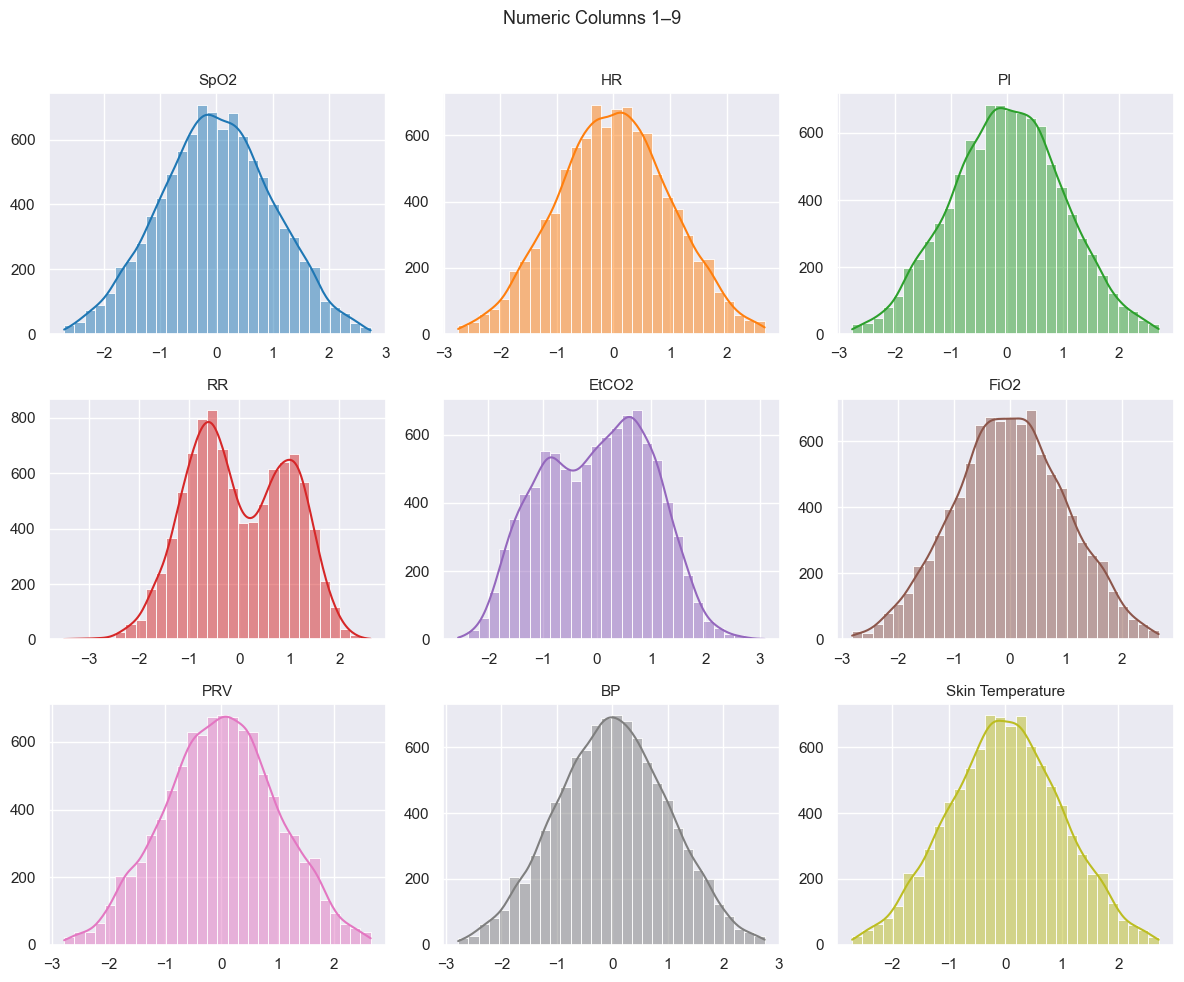

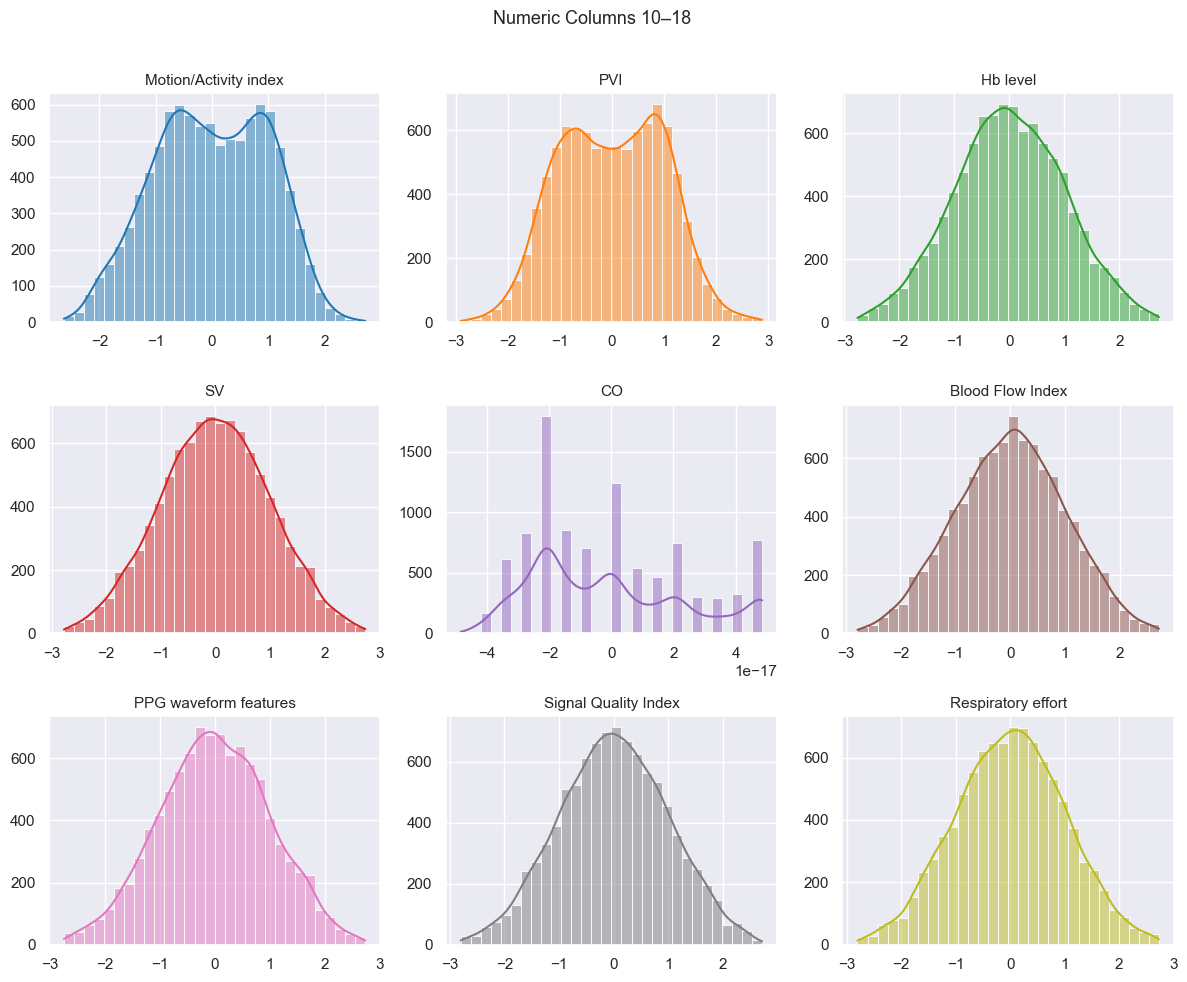

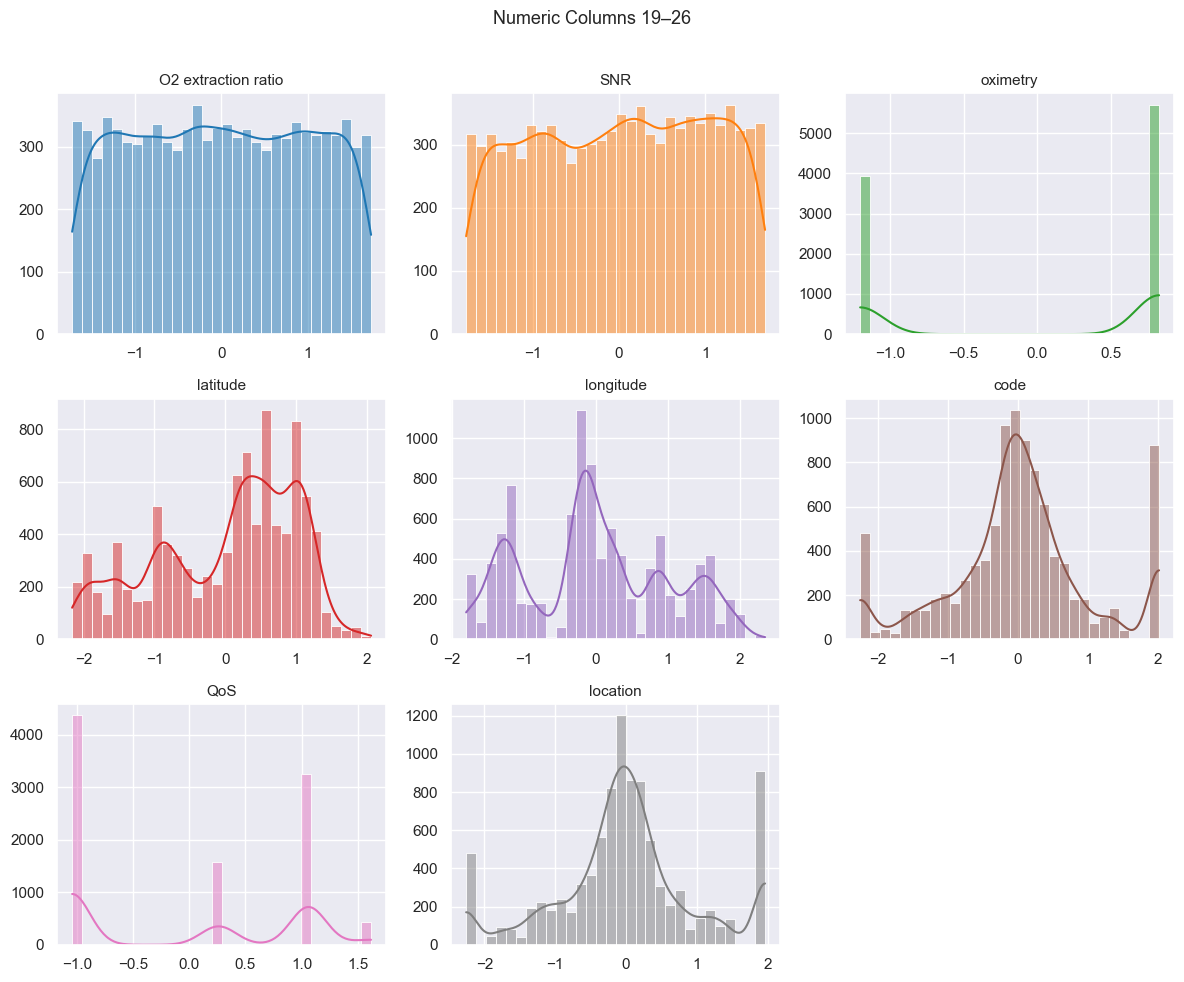

In [88]:
df_train_pt = df_train.copy()
df_train_pt = powerTransform(df_train_pt)

print(df_train_pt.describe())
histogramiada(df_train_pt)

df_train_pt.to_pickle("pickles/df_train_pt.pkl")

- Quantile Transformer

In [89]:
def quantileTransform(df):
    qt = QuantileTransformer(output_distribution='normal', random_state=RANDOM_STATE)
    res = qt.fit_transform(df)
    return pd.DataFrame(res, columns=df_train.columns, index=df_train.index)

              SpO2           HR           PI           RR        EtCO2         FiO2          PRV           BP  Skin Temperature  Motion/Activity index          PVI     Hb level  \
count  9637.000000  9637.000000  9637.000000  9637.000000  9637.000000  9637.000000  9637.000000  9637.000000       9637.000000            9637.000000  9637.000000  9637.000000   
mean     -0.000033     0.000153    -0.000052    -0.000064     0.000255     0.000100     0.000019    -0.000094          0.000021               0.000006     0.000098     0.000048   
std       1.001517     1.002656     1.002237     1.001519     1.001839     1.002759     1.002638     1.001889          1.001843               1.001639     1.001422     1.001654   
min      -5.199338    -5.199338    -5.199338    -5.199338    -5.199338    -5.199338    -5.199338    -5.199338         -5.199338              -5.199338    -5.199338    -5.199338   
25%      -0.674395    -0.674282    -0.675125    -0.674596    -0.675444    -0.674357    -0.674322    

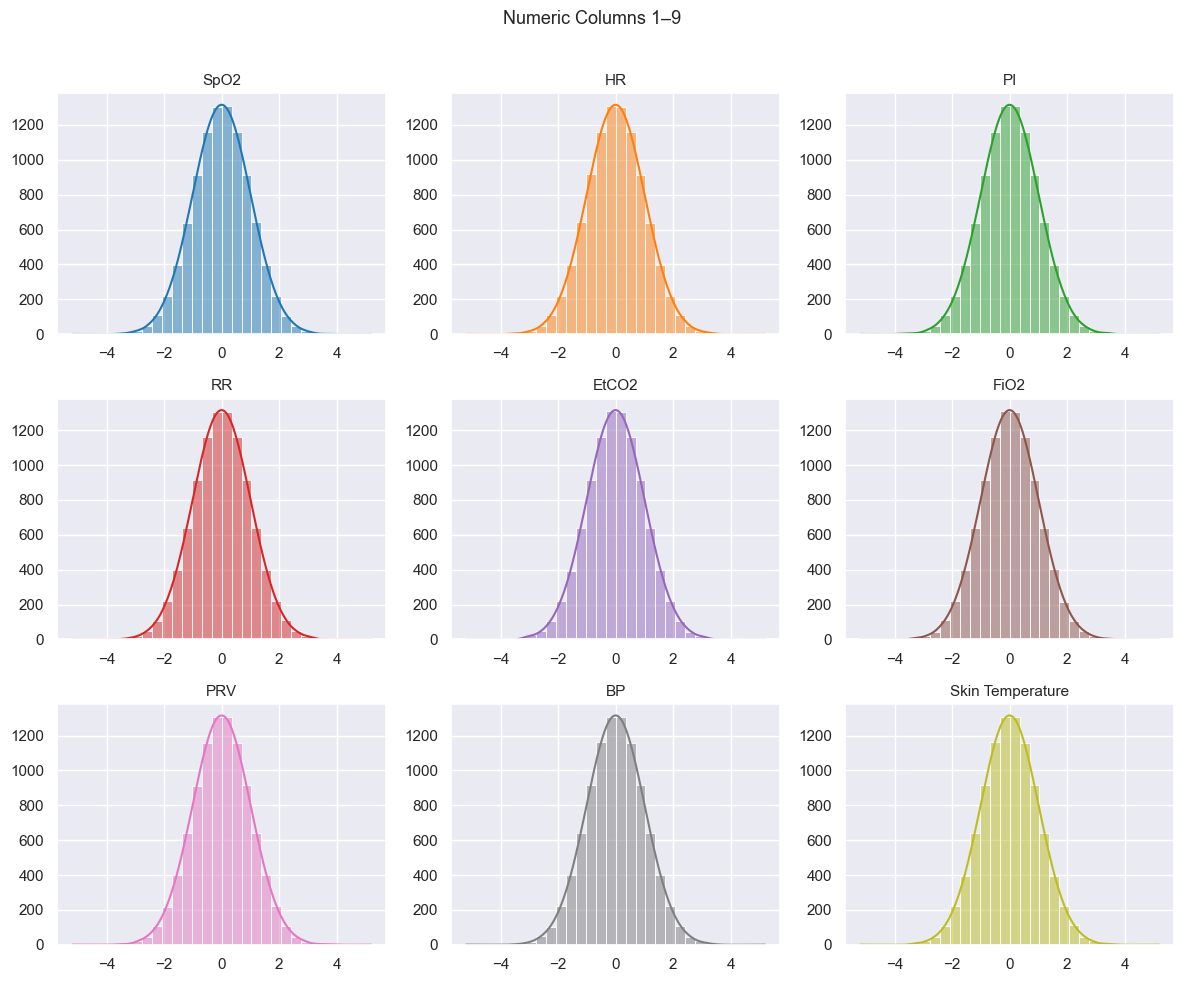

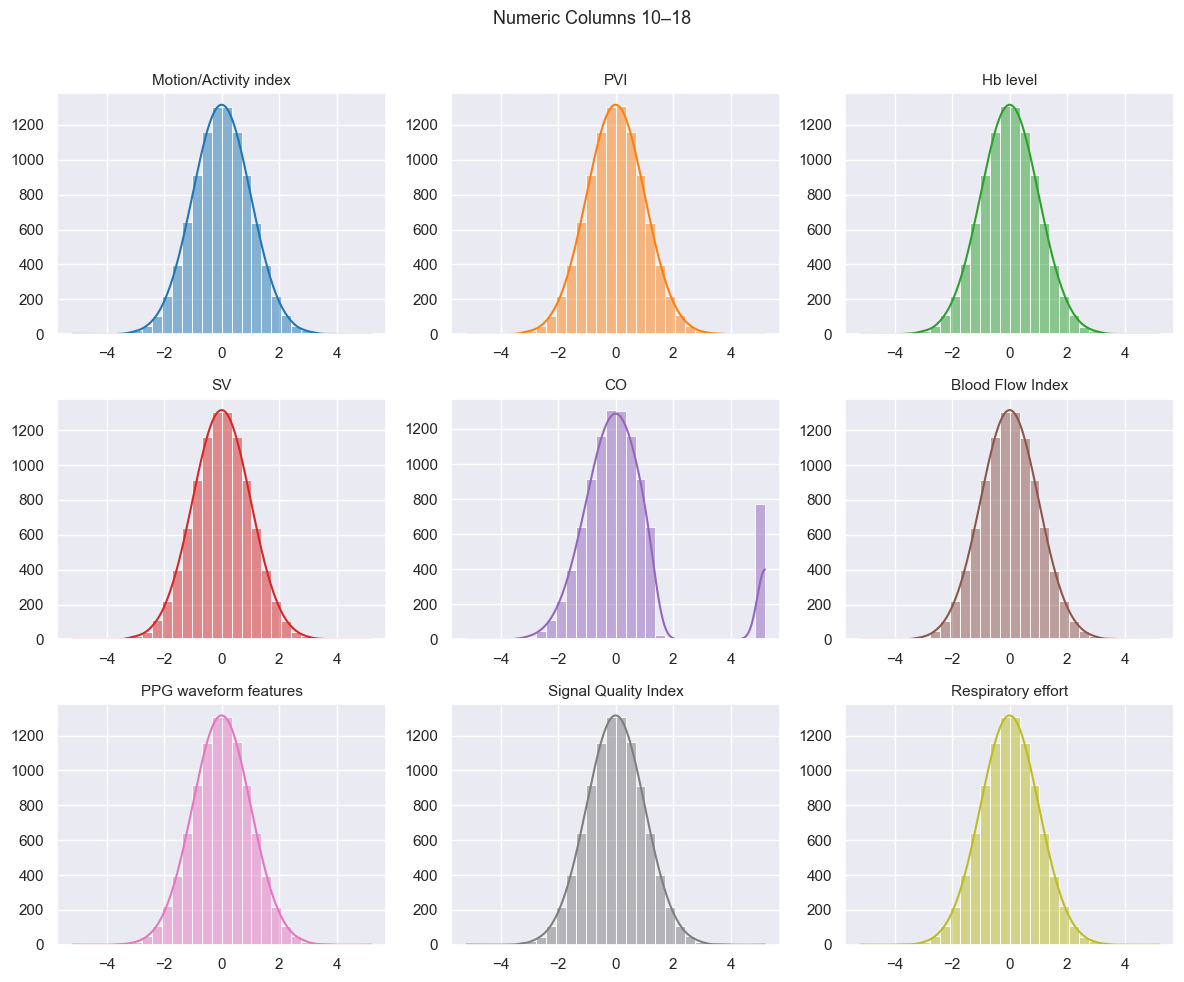

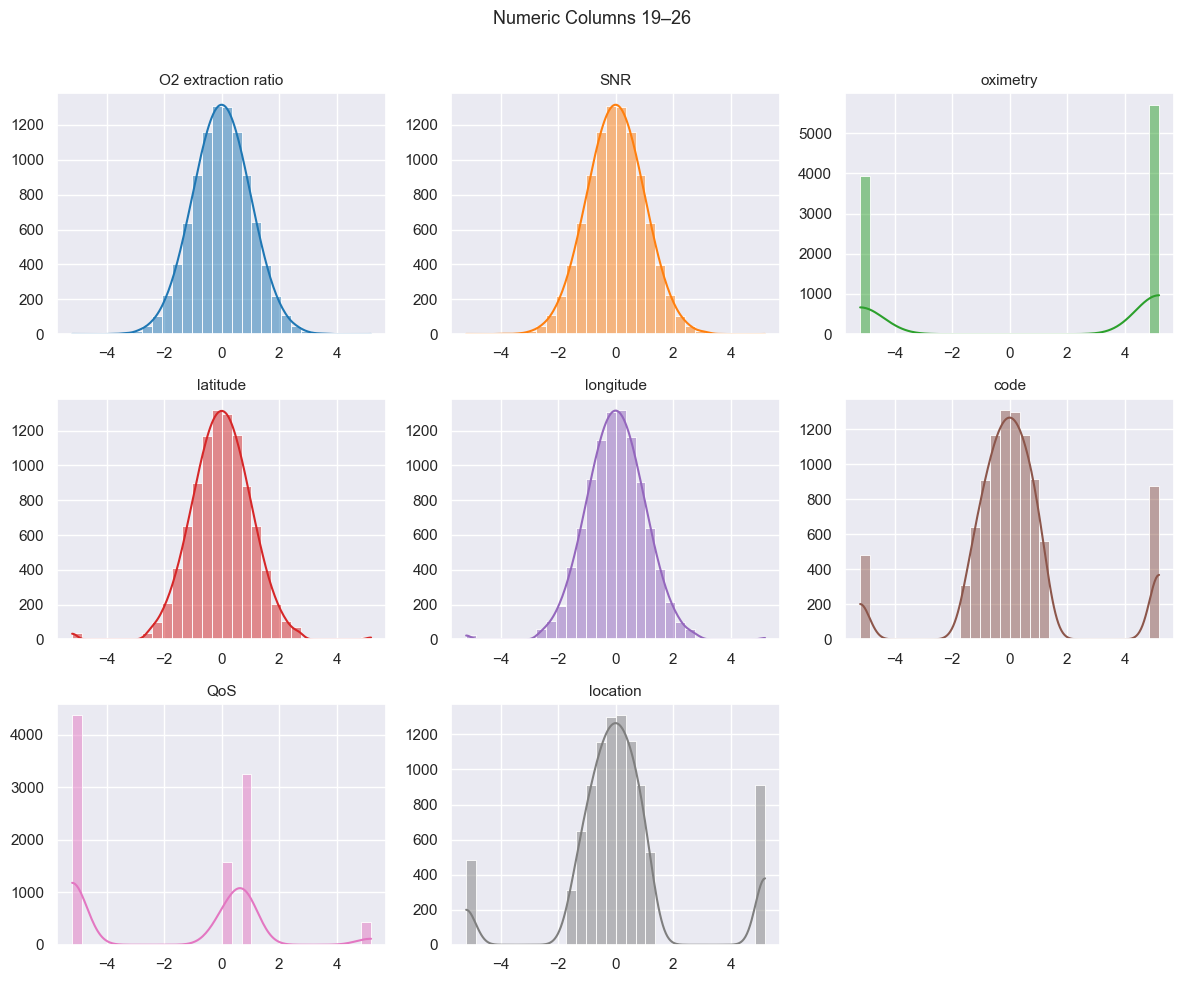

In [90]:
df_train_qt = df_train.copy()
df_train_qt = quantileTransform(df_train_qt)

print(df_train_qt.describe())
histogramiada(df_train_qt)

df_train_qt.to_pickle("pickles/df_train_qt.pkl")

- Standard Scaler

In [91]:
def standardScale(df):
    ss = StandardScaler()
    res = ss.fit_transform(df)
    return pd.DataFrame(res, columns=df_train.columns, index=df_train.index)

               SpO2            HR            PI            RR         EtCO2          FiO2           PRV            BP  Skin Temperature  Motion/Activity index           PVI  \
count  9.637000e+03  9.637000e+03  9.637000e+03  9.637000e+03  9.637000e+03  9.637000e+03  9.637000e+03  9.637000e+03      9.637000e+03           9.637000e+03  9.637000e+03   
mean  -1.498853e-14  2.763427e-15 -1.644195e-16  7.181370e-16 -1.454707e-15  3.122495e-16  2.361226e-16  3.444698e-15     -6.031908e-15           1.194437e-16  2.875497e-16   
std    1.000052e+00  1.000052e+00  1.000052e+00  1.000052e+00  1.000052e+00  1.000052e+00  1.000052e+00  1.000052e+00      1.000052e+00           1.000052e+00  1.000052e+00   
min   -2.715125e+00 -2.715001e+00 -2.733925e+00 -3.076116e+00 -3.039368e+00 -2.730733e+00 -2.700547e+00 -2.760229e+00     -2.703120e+00          -2.899872e+00 -2.689889e+00   
25%   -6.822694e-01 -6.800953e-01 -6.898105e-01 -7.933399e-01 -7.788983e-01 -6.828430e-01 -6.829618e-01 -6.912610e-01   

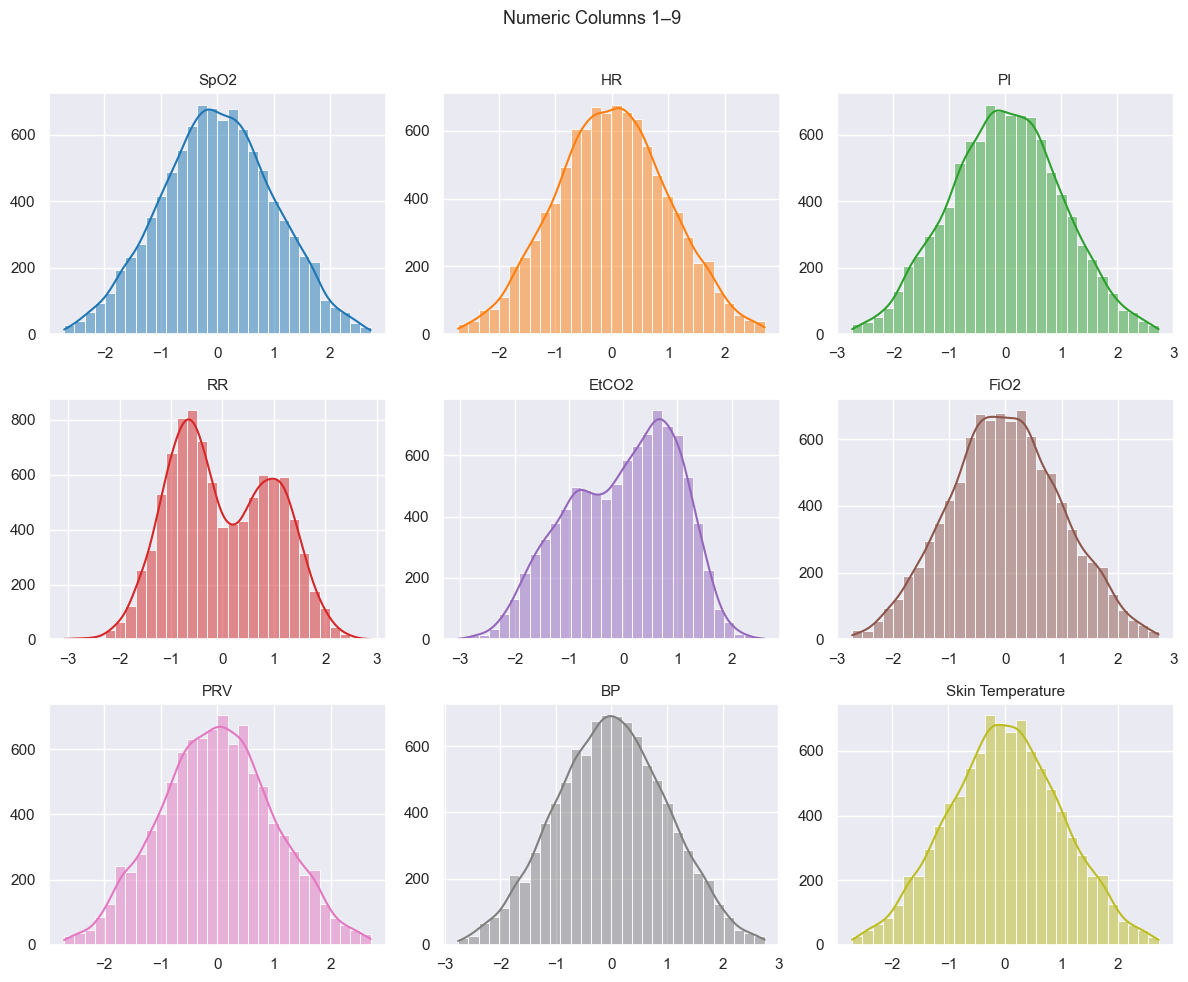

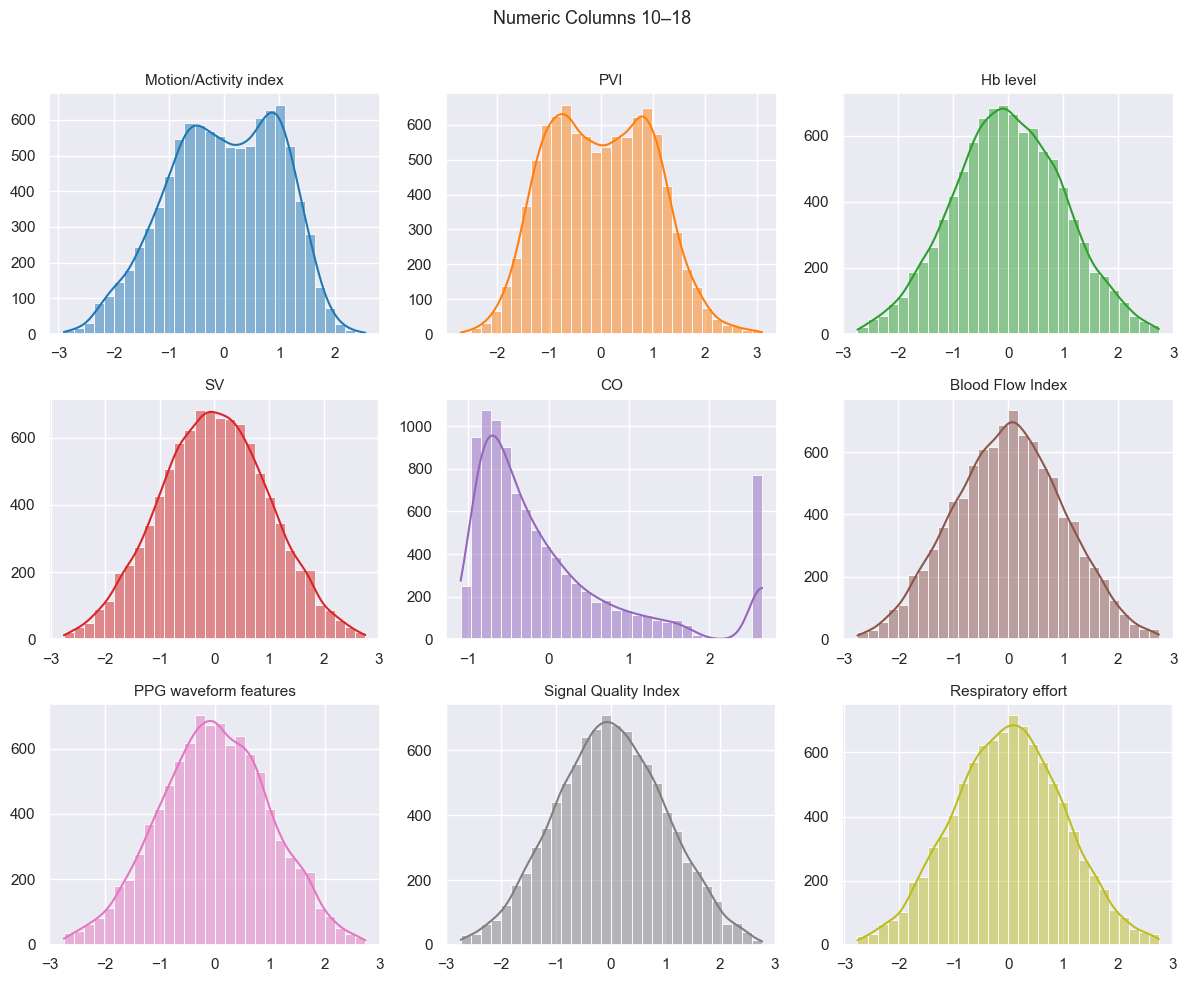

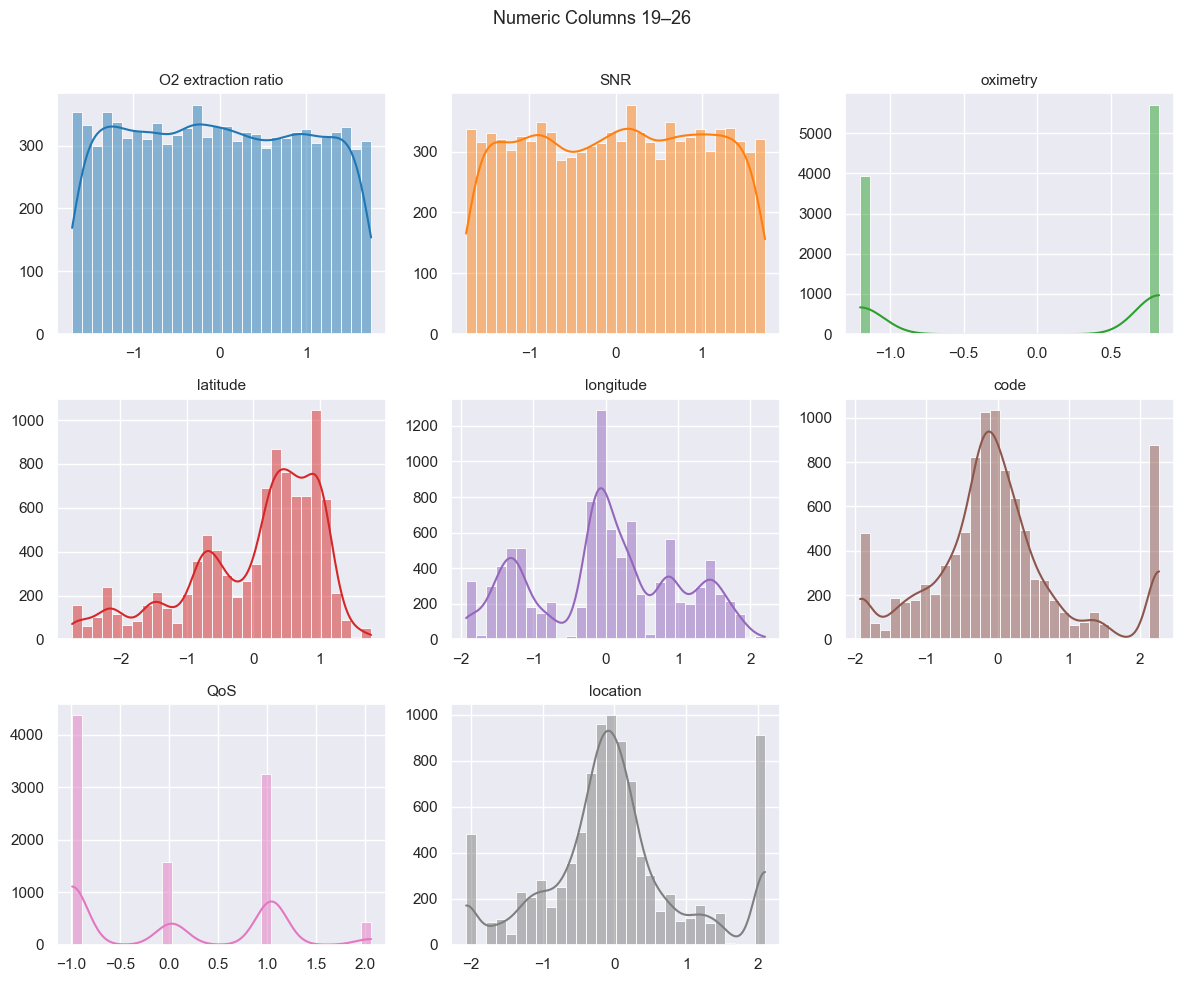

In [92]:
df_train_ss = df_train.copy()
df_train_ss = standardScale(df_train_ss)

print(df_train_ss.describe())
histogramiada(df_train_ss)

df_train_ss.to_pickle("pickles/df_train_ss.pkl")

- MinMax Scaler

In [93]:
def minMaxScale(df):
    mms = MinMaxScaler()
    res = mms.fit_transform(df)
    return pd.DataFrame(res, columns=df_train.columns, index=df_train.index)

              SpO2           HR           PI           RR        EtCO2         FiO2          PRV           BP  Skin Temperature  Motion/Activity index          PVI     Hb level  \
count  9637.000000  9637.000000  9637.000000  9637.000000  9637.000000  9637.000000  9637.000000  9637.000000       9637.000000            9637.000000  9637.000000  9637.000000   
mean      0.499197     0.501410     0.499710     0.516386     0.538417     0.499972     0.499248     0.500240          0.498433               0.531355     0.464688     0.500074   
std       0.183868     0.184691     0.182791     0.167878     0.177157     0.183100     0.184879     0.181241          0.184401               0.183243     0.172763     0.182444   
min       0.000000     0.000000     0.000000     0.000000     0.000000     0.000000     0.000000     0.000000          0.000000               0.000000     0.000000     0.000000   
25%       0.373757     0.375809     0.373625     0.383208     0.400437     0.374950     0.372990    

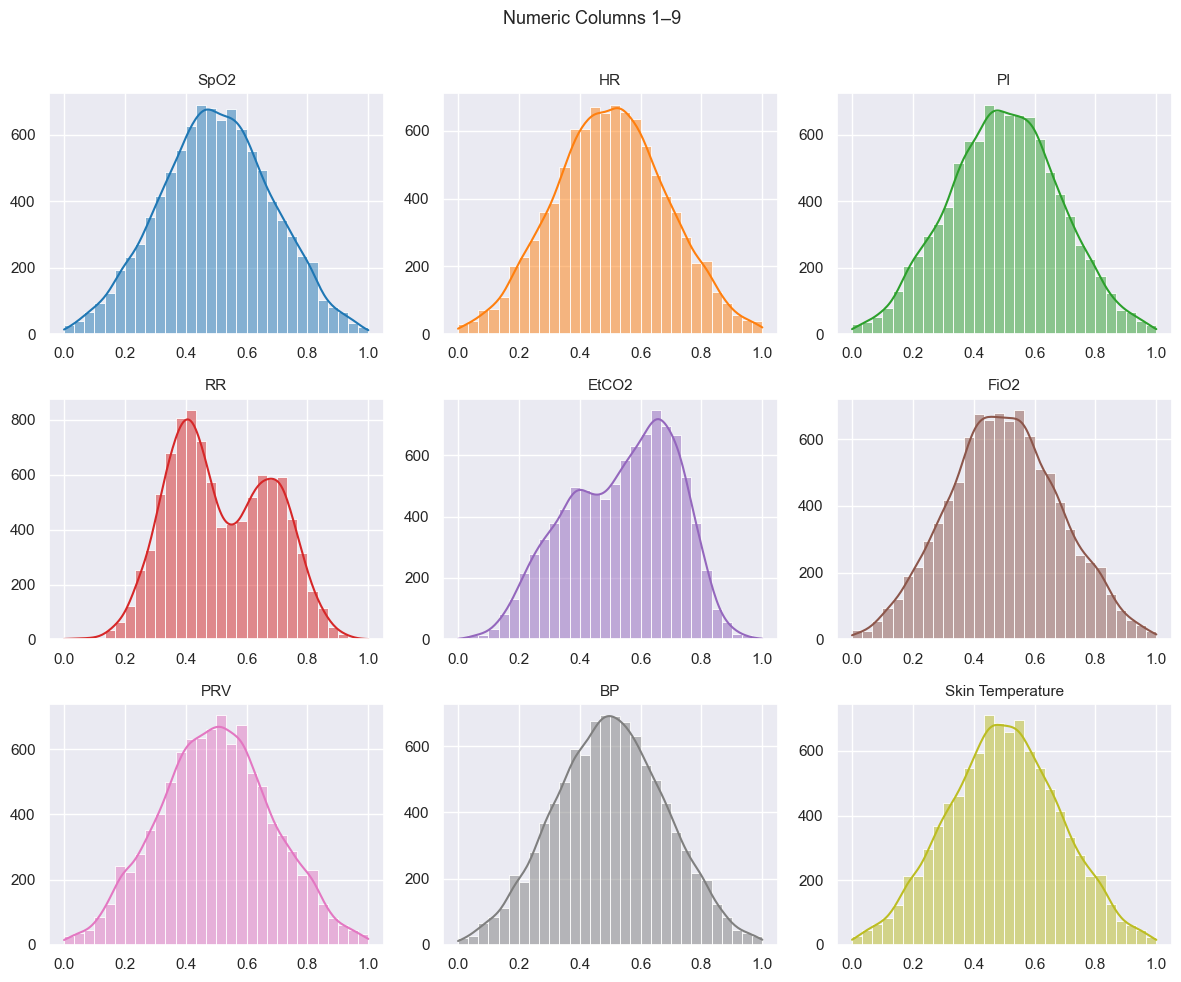

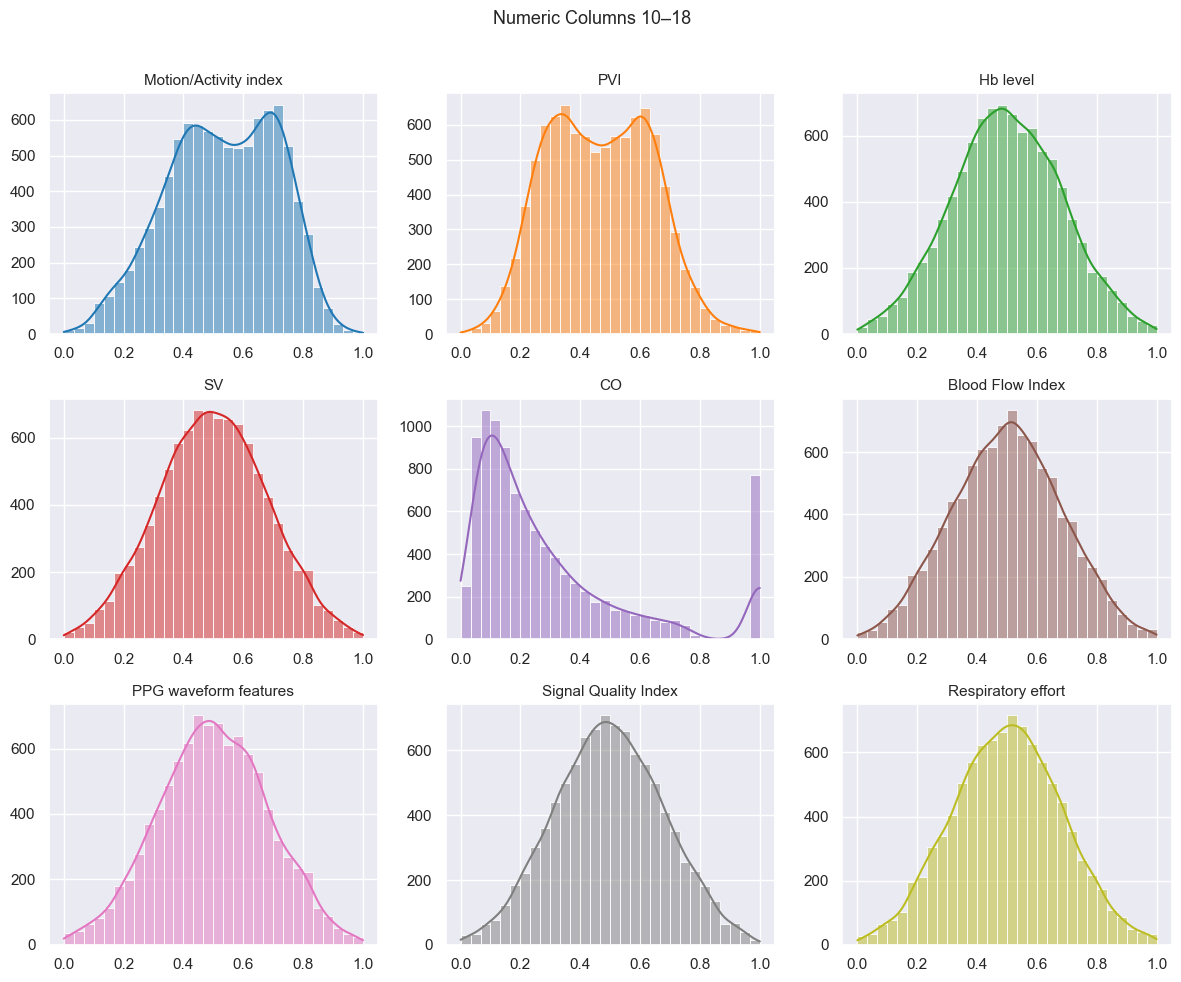

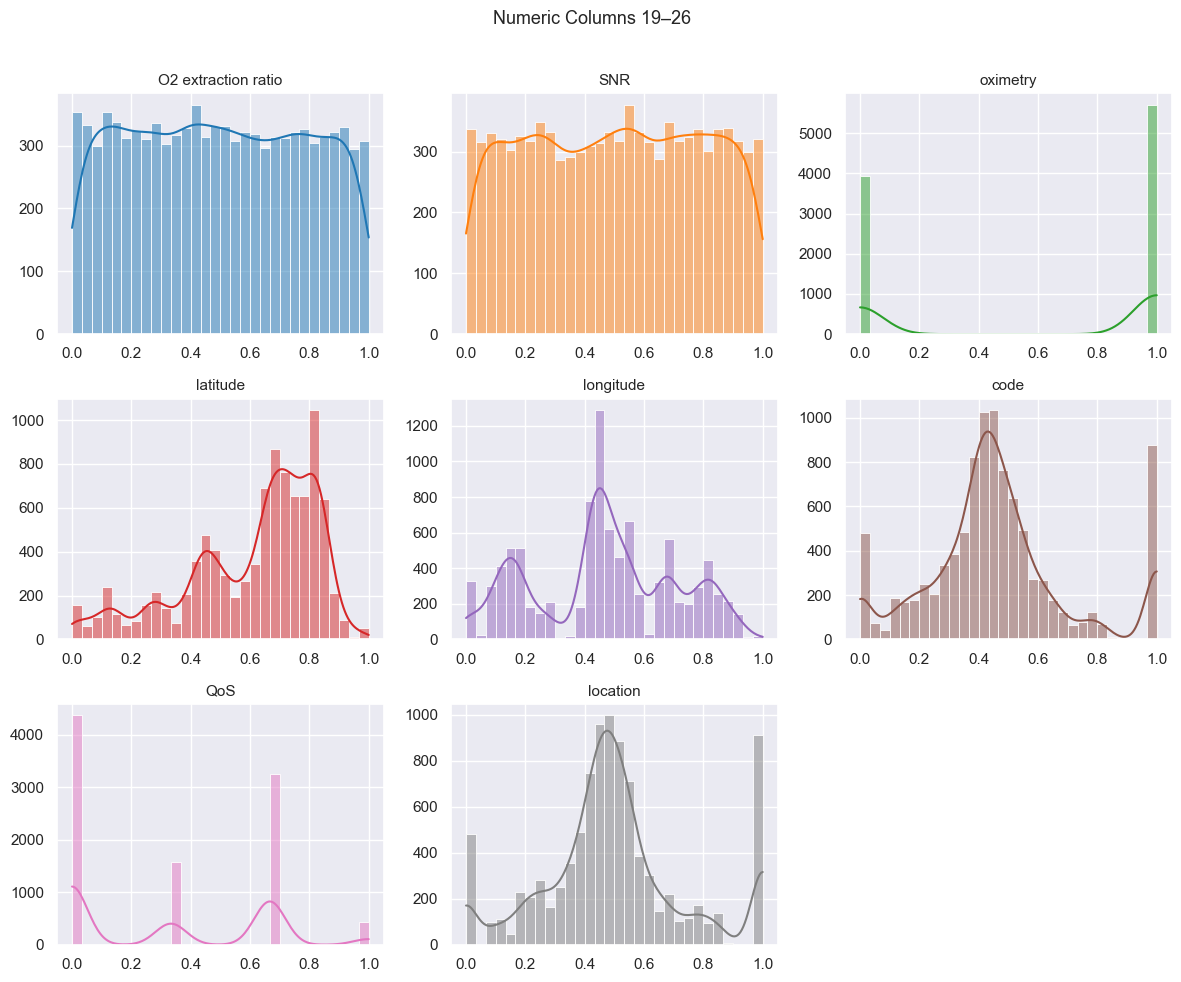

In [94]:
df_train_mms = df_train.copy()
df_train_mms = minMaxScale(df_train_mms)

print(df_train_mms.describe())
histogramiada(df_train_mms)

df_train_mms.to_pickle("pickles/df_train_mms.pkl")

# 2.2 Výber atribútov pre strojové učenie
##### (A-3b) Zistite, ktoré atribúty (features) vo vašich dátach pre ML sú informatívne k predikovanej premennej (minimálne 3 techniky s porovnaním medzi sebou).

##### (B-1b) Zoraďte zistené atribúty v poradí podľa dôležitosti.

##### (C-1b) Zdôvodnite Vaše voľby/rozhodnutie pre realizáciu (t.j. zdokumentovanie)


Kontrola dát

In [95]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9637 entries, 9547 to 3582
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SpO2                   9637 non-null   float64
 1   HR                     9637 non-null   float64
 2   PI                     9637 non-null   float64
 3   RR                     9637 non-null   float64
 4   EtCO2                  9637 non-null   float64
 5   FiO2                   9637 non-null   float64
 6   PRV                    9637 non-null   float64
 7   BP                     9637 non-null   float64
 8   Skin Temperature       9637 non-null   float64
 9   Motion/Activity index  9637 non-null   float64
 10  PVI                    9637 non-null   float64
 11  Hb level               9637 non-null   float64
 12  SV                     9637 non-null   float64
 13  CO                     9637 non-null   float64
 14  Blood Flow Index       9637 non-null   float64
 15  PPG wa

In [96]:
print(f"\nOximetry distribution in df_train:")
print(df_train['oximetry'].value_counts())


Oximetry distribution in df_train:
oximetry
1.0    5706
0.0    3931
Name: count, dtype: int64


Oddelenie features (X) a target premennej (y) pre trénovaciu a testovaciu mnozinu

In [97]:
print(f"   Celkový počet stĺpcov: {df_train.shape[1]}")

numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = df_train.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\n   Numerické stĺpce: {len(numeric_cols)}")
print(f"   Non-numerické stĺpce: {len(non_numeric_cols)}")

   Celkový počet stĺpcov: 26

   Numerické stĺpce: 26
   Non-numerické stĺpce: 0


In [98]:
X_train = df_train.drop('oximetry', axis=1)
y_train = df_train['oximetry']

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")


X_train shape: (9637, 25)
y_train shape: (9637,)


In [99]:
print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"\nTarget distribution (y_train):")
print(y_train.value_counts())
print(f"\nClass balance: {y_train.value_counts(normalize=True)}")


X_train shape: (9637, 25)
y_train shape: (9637,)
Number of features: 25

Target distribution (y_train):
oximetry
1.0    5706
0.0    3931
Name: count, dtype: int64

Class balance: oximetry
1.0    0.592093
0.0    0.407907
Name: proportion, dtype: float64


## A) Feature selection
Zistite, ktoré atribúty (features) vo vašich dátach pre ML sú informatívne k predikovanej premennej (minimálne 3 techniky s porovnaním medzi sebou).

Vyber atribútov s pouzitim 4 roznych techník
1. Correlation-based maethods -> Spearman a Pearson
2. Statistical tests -> Mutual Information
3. Random Forest
4. RFE

In [100]:
# dočasný DataFrame s target premennou pre výpočet korelácie
temp_df = X_train.copy()
temp_df['oximetry'] = y_train

## Correlation-based methods

#### Spearman
Spearman korelácia - Robustná voči outlierom, monotónna závislosť

In [101]:
correlation_spearman = temp_df.corrwith(temp_df['oximetry'], method='spearman').abs()
correlation_spearman = correlation_spearman.drop('oximetry').sort_values(ascending=False)

#### Pearson

In [102]:
correlation_pearson = temp_df.corrwith(temp_df['oximetry'], method='pearson').abs()
correlation_pearson = correlation_pearson.drop('oximetry').sort_values(ascending=False)

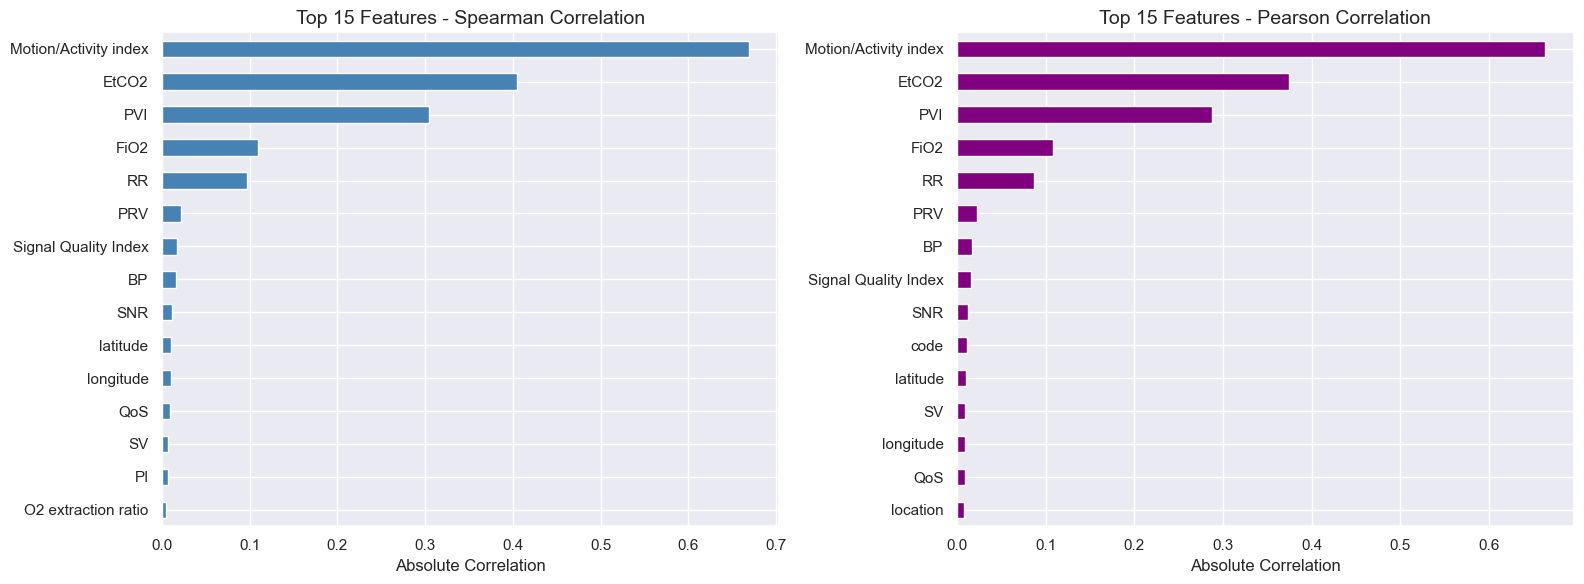

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Spearman
correlation_spearman.head(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Features - Spearman Correlation', fontsize=14)
axes[0].set_xlabel('Absolute Correlation')
axes[0].invert_yaxis()

# Pearson
correlation_pearson.head(15).plot(kind='barh', ax=axes[1], color='purple')
axes[1].set_title('Top 15 Features - Pearson Correlation', fontsize=14)
axes[1].set_xlabel('Absolute Correlation')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

#### top 15 Spearman a Pearson korelácií

In [104]:
top_n = 15

corr_compare = pd.concat([
    correlation_spearman.head(top_n).rename('Spearman'),
    correlation_pearson.head(top_n).rename('Pearson')
], axis=1)

corr_compare = corr_compare.sort_values(by='Spearman', ascending=False)
corr_compare = corr_compare.round(3).fillna('-')

display(corr_compare)


,Spearman,Pearson
Motion/Activity index,0.67,0.663
EtCO2,0.404,0.374
PVI,0.304,0.288
FiO2,0.109,0.108
RR,0.097,0.086
PRV,0.022,0.023
Signal Quality Index,0.018,0.016
BP,0.016,0.017
SNR,0.012,0.012
latitude,0.011,0.01


## Statistical tests
### Mutual Information
MI zachytáva všetky typy závislostí (lineárne aj nelineárne), na rozdiel od korelácie.

In [105]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# oximetry je kategorická => mutual_info_classif

mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

mi_scores_df = (
    pd.DataFrame({'Feature': X_train.columns, 'MI_Score': mi_scores})
    .sort_values('MI_Score', ascending=False)
    .reset_index(drop=True)
)

mi_scores_df.index += 1
mi_scores_df.index.name = 'Poradie'

print("Top 15 - Mutual Information:")
print(mi_scores_df.head(15))

Top 15 - Mutual Information:
                       Feature  MI_Score
Poradie                                 
1        Motion/Activity index  0.287669
2                        EtCO2  0.143596
3                          PVI  0.059791
4                           RR  0.038636
5                           CO  0.009684
6             Blood Flow Index  0.008846
7                         SpO2  0.006093
8                         FiO2  0.005644
9                          PRV  0.004744
10                    location  0.004743
11                   longitude  0.004528
12                          PI  0.004440
13                        code  0.003942
14                         SNR  0.003809
15                    Hb level  0.002771


<Figure size 1000x800 with 0 Axes>

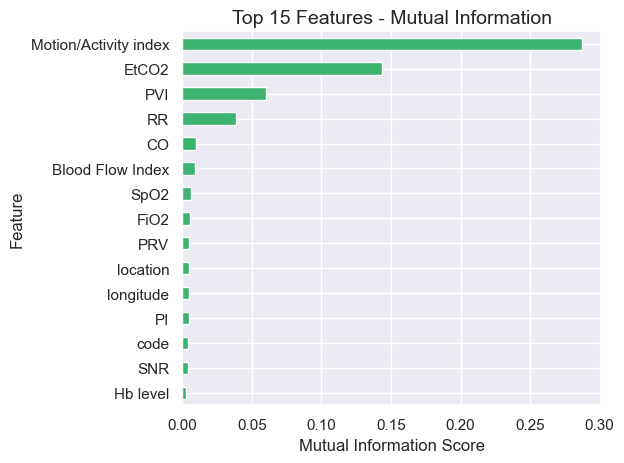

In [106]:
plt.figure(figsize=(10, 8))
mi_scores_df.head(15).plot(x='Feature', y='MI_Score', kind='barh', 
                            color='mediumseagreen', legend=False)
plt.title('Top 15 Features - Mutual Information', fontsize=14)
plt.xlabel('Mutual Information Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Model-based feature importance
### Tree-based Feature Importance (Random Forest)
Model-based metóda - simuluje reálne použitie v ML. RF feature importance ukazuje, ktoré features model skutočne využíva pri rozhodovaní. Je to praktický pohľad z pohľadu ML modelu.

In [107]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_importance = (
    pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': rf.feature_importances_})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

rf_importance.index += 1
rf_importance.index.name = 'Poradie'

print("Top 15 - Random Forest:")
print(rf_importance.head(15))
print(f"\nRandom Forest Train Accuracy: {rf.score(X_train, y_train):.3f}")

Top 15 - Random Forest:
                       Feature  Importance
Poradie                                   
1        Motion/Activity index    0.356775
2                        EtCO2    0.170081
3                          PVI    0.098583
4                           RR    0.059495
5                         FiO2    0.040207
6                          PRV    0.028335
7                           BP    0.014988
8             Skin Temperature    0.014728
9         Signal Quality Index    0.014479
10       PPG waveform features    0.014333
11                         SNR    0.014332
12         O2 extraction ratio    0.014317
13                    Hb level    0.013971
14                        SpO2    0.013937
15            Blood Flow Index    0.013802

Random Forest Train Accuracy: 1.000


<Figure size 1000x800 with 0 Axes>

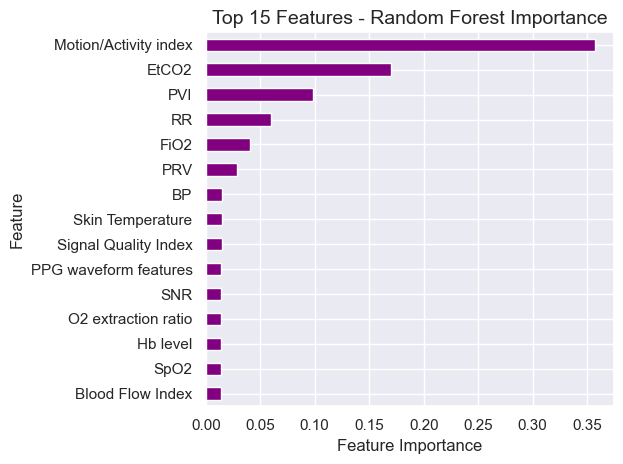

In [108]:
plt.figure(figsize=(10, 8))
rf_importance.head(top_n).plot(x='Feature', y='Importance', kind='barh', 
                             color='purple', legend=False)
plt.title('Top 15 Features - Random Forest Importance', fontsize=14)
plt.xlabel('Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Recursive Feature Elimination (RFE)
Iteratívne odstraňovanie najmenej dôležitých features. RFE simuluje proces, ktorý budete používať v praxi - postupné zlepšovanie modelu odstránením slabých features.


Triedy v y_rfe: [0. 1.]

Top 15 - RFE podľa rankingu:
                  Feature  Ranking  Selected
0                    SpO2        1      True
3                      RR        1      True
5                    FiO2        1      True
4                   EtCO2        1      True
11               Hb level        1      True
10                    PVI        1      True
9   Motion/Activity index        1      True
8        Skin Temperature        1      True
12                     SV        1      True
13                     CO        1      True
18    O2 extraction ratio        1      True
24               location        1      True
23                    QoS        1      True
22                   code        1      True
19                    SNR        1      True


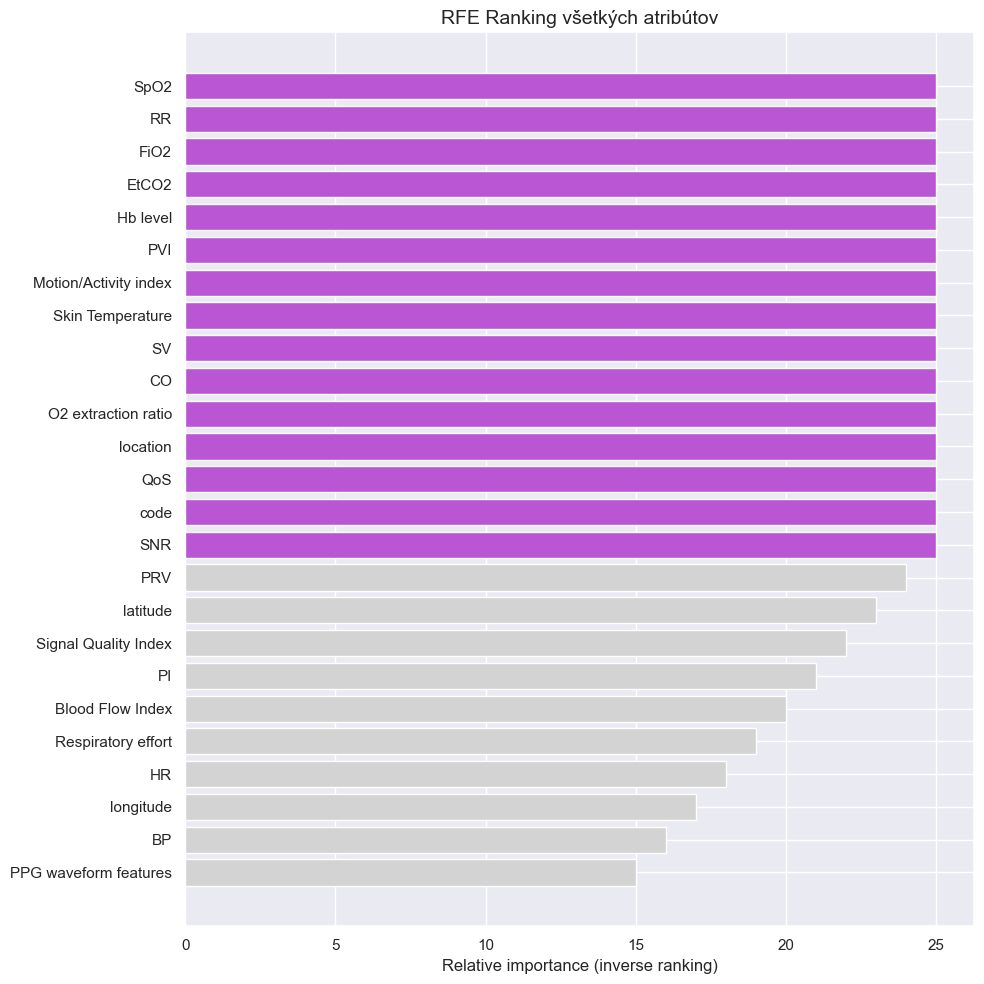

In [109]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# vezmeme len numerické features
X_rfe = X_train.select_dtypes(include=[np.number]).copy()
y_rfe = y_train.copy()

# odstránime riadky s NaN alebo +-inf (v X aj y)
mask = np.isfinite(X_rfe).all(axis=1) & y_rfe.notna()
X_rfe = X_rfe[mask]
y_rfe = y_rfe[mask]

# skontrolujeme, či sú aspoň 2 triedy
print("\nTriedy v y_rfe:", np.unique(y_rfe))

# Logistic Regression pre RFE
estimator = LogisticRegression(
    max_iter=5000,
    solver='liblinear',   # stabilnejší pre RFE a menšie datasety
    random_state=42
)

rfe = RFE(estimator=estimator, n_features_to_select=15, step=1)
rfe.fit(X_rfe, y_rfe)

# tabuľka rankingov
rfe_ranking = pd.DataFrame({
    'Feature': X_rfe.columns,
    'Ranking': rfe.ranking_,
    'Selected': rfe.support_
}).sort_values('Ranking')

print("\nTop 15 - RFE podľa rankingu:")
print(rfe_ranking.head(15))

# graf len pre vybrané features (Ranking == 1)
selected_features = rfe_ranking[rfe_ranking['Selected']]

plt.figure(figsize=(10, 10))
plt.barh(
    rfe_ranking['Feature'],
    (rfe_ranking['Feature'].count() + 1) - rfe_ranking['Ranking'],  # prevrátený ranking
    color=rfe_ranking['Selected'].map({True: 'mediumorchid', False: 'lightgrey'})
)
plt.title('RFE Ranking všetkých atribútov', fontsize=14)
plt.xlabel('Relative importance (inverse ranking)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Dolezitost atribútov
Zoraďte zistené atribúty v poradí podľa dôležitosti.

In [110]:
correlation_spearman = correlation_spearman.reindex(X_train.columns)
correlation_pearson = correlation_pearson.reindex(X_train.columns)
mi_scores = mi_scores_df.set_index('Feature')['MI_Score'].reindex(X_train.columns)
rf_import = rf_importance.set_index('Feature')['Importance'].reindex(X_train.columns)
rfe_rank = rfe_ranking.set_index('Feature')['Ranking'].reindex(X_train.columns)

# spojime vsetky vysledky
comparison_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Spearman': correlation_spearman.values,
    'Pearson': correlation_pearson.values,
    'MI_Score': mi_scores.values,
    'RF_Importance': rf_import.values,
    'RFE_Ranking': rfe_rank.values
})

scaler = MinMaxScaler()
comparison_df[['Spearman', 'Pearson', 'MI_Score', 'RF_Importance']] = scaler.fit_transform(
    comparison_df[['Spearman', 'Pearson', 'MI_Score', 'RF_Importance']]
)

# RFE ranking - nižší ranking = lepší
comparison_df['RFE_Score'] = 1 - (comparison_df['RFE_Ranking'] / comparison_df['RFE_Ranking'].max())

# priemerná dôležitosť
comparison_df['Average_Score'] = comparison_df[['Spearman', 'Pearson', 'MI_Score', 
                                                  'RF_Importance', 'RFE_Score']].mean(axis=1)

# zoradenie podla average_score
final_ranking = comparison_df.sort_values('Average_Score', ascending=False)

final_ranking = final_ranking.reset_index(drop=True)  # reset starého indexu
final_ranking.index += 1  # nech sa začína od 1, nie od 0
final_ranking.index.name = 'Poradie' 

cols = ['Feature', 'Spearman', 'Pearson', 'MI_Score', 'RF_Importance',
        'RFE_Ranking', 'RFE_Score', 'Average_Score']

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

In [111]:
n_top = 10  # počet zvýraznených prvkov

def highlight_top_n_text(row):
    if row.name <= n_top:
        return ['color: #008000; font-weight: bold;' for _ in row]  # zelený text
    return ['' for _ in row]

display(
    final_ranking[cols]
    .round(4)
    .style
    .background_gradient(subset=['Average_Score'], cmap='YlOrRd')  # gradient ostane
    .set_caption(f"Porovnanie metód – TOP {n_top} označené zeleným textom")
)


,Feature,Spearman,Pearson,MI_Score,RF_Importance,RFE_Ranking,RFE_Score,Average_Score
Poradie,,,,,,,,
1,Motion/Activity index,1.000000,1.000000,1.000000,1.000000,1,0.909100,0.981800
2,EtCO2,0.603800,0.564300,0.499200,0.471300,1,0.909100,0.609500
3,PVI,0.454700,0.433800,0.207800,0.268800,1,0.909100,0.454800
4,RR,0.145200,0.129800,0.134300,0.158100,1,0.909100,0.295300
5,FiO2,0.163300,0.162800,0.019600,0.103400,1,0.909100,0.271600
6,SNR,0.018000,0.017500,0.013200,0.030100,1,0.909100,0.197600
7,PRV,0.032800,0.034200,0.016500,0.069800,2,0.818200,0.194300
8,CO,0.001600,0.000000,0.033700,0.022800,1,0.909100,0.193400
9,code,0.003300,0.015800,0.013700,0.020400,1,0.909100,0.192500


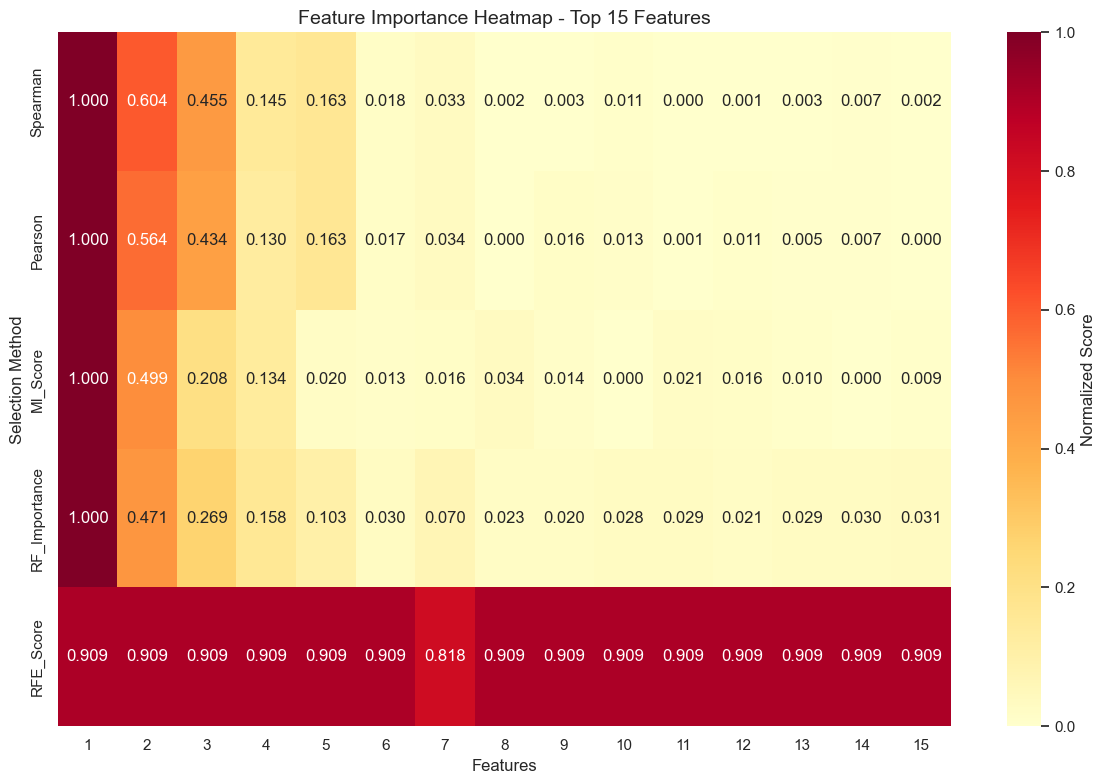

In [112]:
# Heatmap
plt.figure(figsize=(12, 8))
top_features = final_ranking.head(15)
heatmap_data = top_features[['Spearman', 'Pearson', 'MI_Score', 
                               'RF_Importance', 'RFE_Score']].T

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', 
            cbar_kws={'label': 'Normalized Score'})
plt.title('Feature Importance Heatmap - Top 15 Features', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Selection Method')
plt.tight_layout()
plt.show()

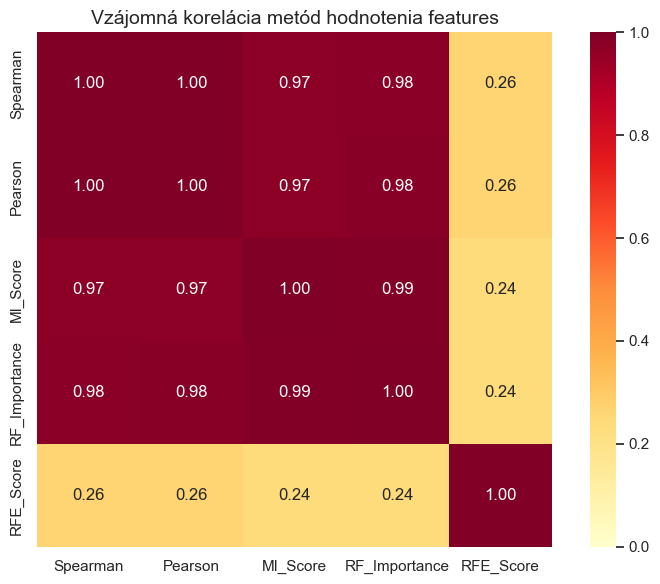

In [113]:
methods_corr = comparison_df[['Spearman', 'Pearson', 'MI_Score', 'RF_Importance', 'RFE_Score']].dropna().corr()

plt.figure(figsize=(8,6))
sns.heatmap(methods_corr, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1, square=True)
plt.title("Vzájomná korelácia metód hodnotenia features", fontsize=14)
plt.tight_layout()
plt.show()

### Top 10 najdôležitejších atribútov (priemerné skóre)

,Feature,Spearman,Pearson,MI_Score,RF_Importance,RFE_Ranking,RFE_Score,Average_Score
Poradie,,,,,,,,
1,Motion/Activity index,1.000000,1.000000,1.000000,1.000000,1,0.909100,0.981800
2,EtCO2,0.603800,0.564300,0.499200,0.471300,1,0.909100,0.609500
3,PVI,0.454700,0.433800,0.207800,0.268800,1,0.909100,0.454800
4,RR,0.145200,0.129800,0.134300,0.158100,1,0.909100,0.295300
5,FiO2,0.163300,0.162800,0.019600,0.103400,1,0.909100,0.271600
6,SNR,0.018000,0.017500,0.013200,0.030100,1,0.909100,0.197600
7,PRV,0.032800,0.034200,0.016500,0.069800,2,0.818200,0.194300
8,CO,0.001600,0.000000,0.033700,0.022800,1,0.909100,0.193400
9,code,0.003300,0.015800,0.013700,0.020400,1,0.909100,0.192500


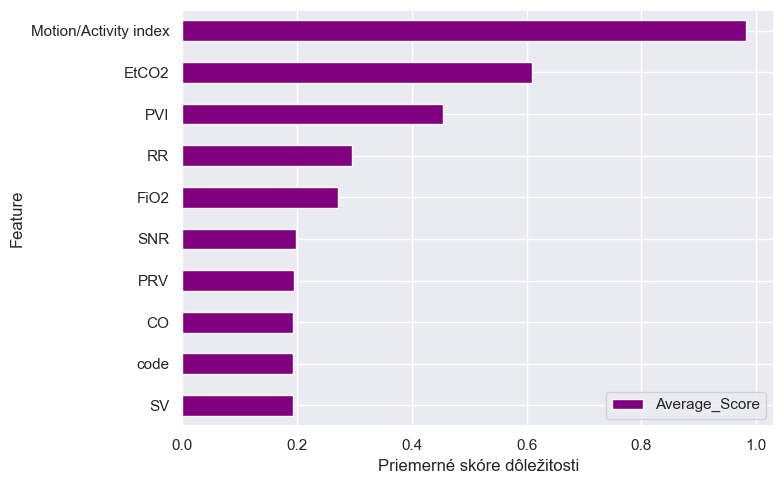

In [114]:
final_ranking.to_csv('feature_importance_ranking.csv', index=False)

cols = ['Feature', 'Spearman', 'Pearson', 'MI_Score', 'RF_Importance',
        'RFE_Ranking', 'RFE_Score', 'Average_Score']

display(
    final_ranking.head(10)[cols]
    .round(4)
    .style.background_gradient(subset=['Average_Score'], cmap='YlOrRd')
)

final_ranking.head(10).plot.barh(
    x='Feature', y='Average_Score', color='purple', figsize=(8,5))
plt.gca().invert_yaxis()
plt.xlabel('Priemerné skóre dôležitosti')
plt.tight_layout()
plt.show()

### Method comparison
1. **Spearman Correlation** - Robustná voči outlierom, monotónna závislosť
2. **Pearson Correlation**  - Citlivá na outliery, zachytáva lineárne vzťahy
3. **Mutual Information**   - Zachytáva nelineárne vzťahy medzi premennými
4. **Random Forest**        - Ensemble metóda, poskytuje praktický pohľad na významnosť
5. **RFE (Logistic Reg.)**  - Iteratívne odstraňovanie menej dôležitých atribútov

## C) Interpretácia výsledkov feature selection
Zdôvodnite Vaše voľby/rozhodnutie pre realizáciu (t.j. zdokumentovanie)

### Prečo sme používali neskalované dáta?
Feature selection som robila na pôvodných, neskalovaných dátach, a to z niekoľkých dôvodov:

1. Lepšia čitateľnosť výsledkov: korelácie a vzťahy sa dajú jednoduchšie vysvetliť, keď pracujeme s reálnymi jednotkami (napr. SpO₂ v %).

2. Škálovanie nemení význam featureov: dôležitosť premennej by mala vychádzať z jej vplyvu, nie z toho, ako je škálovaná.

3. Jednotnosť: všetky metódy (Spearman, Pearson, MI, Random Forest, RFE) používajú rovnaké vstupné dáta, takže sa dajú lepšie porovnať.

### Prečo práve tieto 4 metódy?
#### Korelačné metódy (Spearman a Pearson)
Použila som ich preto, že zachytávajú priame vzťahy medzi premennými a cieľom.
- **Spearman** je odolný voči odľahlým hodnotám (čo sa u mňa vyskytuje pri indexoch Motion/Activity alebo PI).
- **Pearson** je vhodný, keď je vzťah silne lineárny.
Tieto metódy sú rýchle a ľahko interpretovateľné, ale nezachytia nelineárne väzby.

#### Mutual Information (MI)
MI vie zachytiť aj nelineárne závislosti, čo je pri fyziologických dátach dôležité.
- SpO₂ má prahový efekt (pod 90 % prudko klesá),
- HR môže mať tvar U-krivky (nízke aj vysoké hodnoty sú problematické).
Je to teda univerzálnejší prístup, no môže byť citlivejší na spôsob diskretizácie číselných dát.

#### Random Forest Feature Importance
Táto metóda už viac simuluje reálne správanie modelov. Meria, o koľko sa zníži chyba (Gini impurity), keď sa feature použije v rozhodovacom strome.
- Výhoda je, že zachytáva interakcie medzi premennými a zvláda aj nelineárne vzťahy.
- Nevýhoda – trochu zvýhodňuje premenné, ktoré majú veľa unikátnych hodnôt (vysokú kardinalitu).

#### Recursive Feature Elimination (RFE)
Ide o iteratívny prístup, ktorý v každom kroku odstráni najmenej dôležitý feature a model znovu pretrénuje.
Takto sa hľadá optimálna podmnožina najlepších features.
Výhoda je, že berie do úvahy vzájomné kombinácie, no je výpočtovo náročnejší a závisí od použitého modelu.

### Prečo combined ranking?

**Dôvod pre agregáciu:**
Každá metóda má svoje slabiny:
- Korelácie vidia len lineárne vzťahy,
- MI je citlivá na binning,
- RF preferuje premenné s veľa hodnotami,
- RFE závisí od zvoleného modelu.
Preto som spravila **vážený priemer** skóre – ten spája silné stránky všetkých prístupov a zmierňuje ich nedostatky.


### Interpretácia TOP features:

**1. SpO₂ (Oxygen Saturation)**
- Najdôležitejšia premenná vo všetkých metódach
- Priamy fyziologický ukazovateľ okysličenia krvi
- Je priamo spojená s oximetriou – ide o hlavný ukazovateľ okysličenia krvi

**2. PI (Perfusion Index)** - TOP vo všetkých metódach
- Meria silu pulzného signálu
- Ukazuje silu pulzného signálu a kvalitu periférneho prekrvenia, čo súvisí s presnosťou merania

**3. Motion/Activity index** - Vysoká importance
- Pohyb má veľký vplyv na kvalitu merania – môže spôsobovať šum alebo falošné hodnoty

**4. Geografické features (latitude, longitude)** - Nízka importance
- Očakávaný výsledok - poloha by nemala priamo ovplyvňovať fyziológiu
- Jediná slabá väzba by mohla súvisieť s nadmorskou výškou, ale v dátach sa to nepotvrdilo.


=== Zhoda medzi feature selection metódami ===



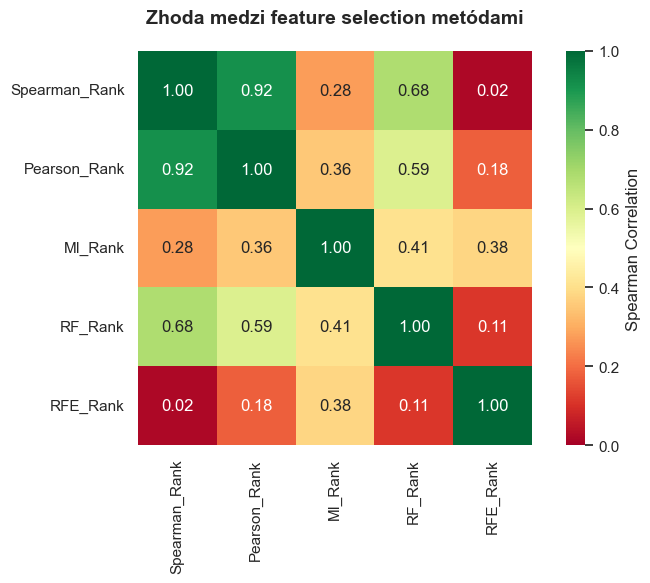

Interpretácia:
- Hodnoty blízko 1.0 = vysoká zhoda (metódy sa zhodujú na dôležitosti)
- Hodnoty blízko 0.0 = nízka zhoda (metódy vidia dôležitosť inak)

Priemerná zhoda: 0.392


In [115]:
# Vytvorenie DataFrame s poradiami jednotlivých metód
feature_ranking = final_ranking.copy()

# rand pre kazdy stlpec
feature_ranking['Spearman_Rank'] = feature_ranking['Spearman'].rank(ascending=False)
feature_ranking['Pearson_Rank'] = feature_ranking['Pearson'].rank(ascending=False)
feature_ranking['MI_Rank'] = feature_ranking['MI_Score'].rank(ascending=False)
feature_ranking['RF_Rank'] = feature_ranking['RF_Importance'].rank(ascending=False)
feature_ranking['RFE_Rank'] = feature_ranking['RFE_Score'].rank(ascending=False)

# Porovnanie zhody medzi metódami - Spearman korelácia medzi rankami
print("\n=== Zhoda medzi feature selection metódami ===\n")

ranking_comparison = feature_ranking[
    ['Spearman_Rank', 'Pearson_Rank', 'MI_Rank', 'RF_Rank', 'RFE_Rank']
].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(ranking_comparison, annot=True, fmt='.2f', cmap='RdYlGn', 
            center=0.5, vmin=0, vmax=1, square=True,
            cbar_kws={'label': 'Spearman Correlation'})
plt.title('Zhoda medzi feature selection metódami', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("Interpretácia:")
print("- Hodnoty blízko 1.0 = vysoká zhoda (metódy sa zhodujú na dôležitosti)")
print("- Hodnoty blízko 0.0 = nízka zhoda (metódy vidia dôležitosť inak)")
print(f"\nPriemerná zhoda: "
      f"{ranking_comparison.values[np.triu_indices_from(ranking_comparison.values, k=1)].mean():.3f}")


In [116]:
# Predpoklad: feature_ranking = final_ranking (už zoradené podľa Average_Score)
feature_ranking = final_ranking.copy()

print("\n" + "="*60)
print("TOP 5 najdôležitejších features:")
print("="*60)

top_5 = feature_ranking.head(5)

for order, (_, row) in enumerate(top_5.iterrows(), start=1):
    print(f"\n{order}. {row['Feature']}")
    print(f"   Average score: {row['Average_Score']:.4f}")
    print(f"   Spearman: {row['Spearman']:.3f} | Pearson: {row['Pearson']:.3f}")
    print(f"   MI: {row['MI_Score']:.3f} | RF: {row['RF_Importance']:.3f} | "
          f"RFE score: {row['RFE_Score']:.3f} (rank {int(row['RFE_Ranking'])})")

print("\n" + "="*60)
print("BOTTOM 5 najmenej dôležitých features:")
print("="*60)

bottom_5 = feature_ranking.tail(5)

for order, (_, row) in enumerate(bottom_5.iterrows(), start=1):
    print(f"\n{len(feature_ranking) - 5 + order}. {row['Feature']}")
    print(f"   Average score: {row['Average_Score']:.4f}")
    print(f"   Spearman: {row['Spearman']:.3f} | Pearson: {row['Pearson']:.3f}")
    print(f"   MI: {row['MI_Score']:.3f} | RF: {row['RF_Importance']:.3f} | "
          f"RFE score: {row['RFE_Score']:.3f} (rank {int(row['RFE_Ranking'])})")

print("\n" + "="*60)
print(f"TOP features ({top_5['Feature'].tolist()}) považujeme za kľúčové vstupy pre modely.")
print(f"\nBOTTOM features ({bottom_5['Feature'].tolist()}) sú kandidáti na odstránenie alebo ďalšie overenie.")
print("\nVo fáze 3 otestujeme modely s plnou sadou aj s redukovanou sadou atribútov.")


TOP 5 najdôležitejších features:

1. Motion/Activity index
   Average score: 0.9818
   Spearman: 1.000 | Pearson: 1.000
   MI: 1.000 | RF: 1.000 | RFE score: 0.909 (rank 1)

2. EtCO2
   Average score: 0.6095
   Spearman: 0.604 | Pearson: 0.564
   MI: 0.499 | RF: 0.471 | RFE score: 0.909 (rank 1)

3. PVI
   Average score: 0.4548
   Spearman: 0.455 | Pearson: 0.434
   MI: 0.208 | RF: 0.269 | RFE score: 0.909 (rank 1)

4. RR
   Average score: 0.2953
   Spearman: 0.145 | Pearson: 0.130
   MI: 0.134 | RF: 0.158 | RFE score: 0.909 (rank 1)

5. FiO2
   Average score: 0.2716
   Spearman: 0.163 | Pearson: 0.163
   MI: 0.020 | RF: 0.103 | RFE score: 0.909 (rank 1)

BOTTOM 5 najmenej dôležitých features:

21. Respiratory effort
   Average score: 0.0801
   Spearman: 0.004 | Pearson: 0.004
   MI: 0.000 | RF: 0.029 | RFE score: 0.364 (rank 7)

22. HR
   Average score: 0.0608
   Spearman: 0.003 | Pearson: 0.004
   MI: 0.000 | RF: 0.025 | RFE score: 0.273 (rank 8)

23. longitude
   Average score: 0.0

In [117]:
feature_ranking

,Feature,Spearman,Pearson,MI_Score,RF_Importance,RFE_Ranking,RFE_Score,Average_Score
Poradie,,,,,,,,
1,Motion/Activity index,1.000000,1.000000,1.000000,1.000000,1,0.909091,0.981818
2,EtCO2,0.603821,0.564342,0.499173,0.471254,1,0.909091,0.609536
3,PVI,0.454651,0.433808,0.207847,0.268761,1,0.909091,0.454831
4,RR,0.145163,0.129815,0.134307,0.158057,1,0.909091,0.295287
5,FiO2,0.163256,0.162787,0.019622,0.103430,1,0.909091,0.271637
6,SNR,0.017996,0.017493,0.013240,0.030147,1,0.909091,0.197593
7,PRV,0.032767,0.034215,0.016491,0.069806,2,0.818182,0.194292
8,CO,0.001566,0.000000,0.033663,0.022813,1,0.909091,0.193427
9,code,0.003342,0.015849,0.013703,0.020379,1,0.909091,0.192473


# 2.3  Replikovateľnosť predspracovania

##### (A-3b) Upravte váš kód realizujúci predspracovanie trénovacej množiny tak, aby ho bolo možné bez ďalších úprav znovu použiť na predspracovanie testovacej množiny v kontexte strojového učenia.
##### (B-2b) Využite možnosti sklearn.pipeline

### Problém v pôvodnom workflow

V časti 2.1 workflow sme urobili predspracovanie (encoding kategórií, čistenie outlierov, odstránenie `revision`) len na trénovacej množine `df_train`. Dataset `df_test` ostal v pôvodnom stave s kategóriami (`code`, `location`, `QoS`) v string forme.

To viedlo k tomu, že:

- `X_train` obsahoval už zakódované numerické hodnoty,
- `X_test` stále obsahoval stringy,
- nebolo možné korektne spustiť feature selection a škálovanie na test dátach,
- nebolo možné použiť uložené transformácie (scalery, power transform),
- každý ML model zlyhával pri predikcii na testovacích dátach kvôli nezhode vstupných premenných.

### Riešenie

1. **Odstránili sme problémové kategórie** (`code`, `location`, `QoS`, `revision`) z oboch datasetov (`df_train` aj `df_test`), aby mali rovnakú štruktúru.
2. **Zachovali sme všetky numerické features** (oximetrické signály a odvodené štatistiky), ktoré sú vhodné na priame použitie v modeli.
3. **Zabezpečili sme konzistenciu** medzi train a test tak, aby mali identické stĺpce v rovnakom poradí.

Tieto upravené dáta potom používame:
- pre škálovanie a transformácie,
- pre tréning a vyhodnotenie modelov.


In [118]:
# 1. Identifikácia problémových stĺpcov

print("\n1. Kontrola typov dát...")
print(f"   df_train shape: {df_train.shape}")
print(f"   df_test shape: {df_test.shape}")

# Stĺpce ktoré sú v df_test non-numeric
test_non_numeric = df_test.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\n   Non-numerické stĺpce v df_test: {test_non_numeric}")

# Pridáme aj 'revision' ak existuje (aj keď je numeric, nechceme ho)
if 'revision' in df_test.columns:
    test_non_numeric.append('revision')
    
# Odstránime duplicity
cols_to_remove = list(set(test_non_numeric))

print(f"   Stĺpce na odstránenie: {cols_to_remove}")

# 2. Odstránenie problémových stĺpcov

if cols_to_remove:
    print(f"\n2. Odstraňujem stĺpce z oboch datasetov...")
    
    for col in cols_to_remove:
        if col in df_train.columns:
            df_train = df_train.drop(columns=[col])
            print(f"Odstránený z df_train: {col}")
            
        if col in df_test.columns:
            df_test = df_test.drop(columns=[col])
            print(f"Odstránený z df_test: {col}")
else:
    print("\n2. Žiadne stĺpce na odstránenie")

# 3. Finálna kontrola

print(f"\n3. Finálna kontrola:")
print(f"   df_train shape: {df_train.shape}")
print(f"   df_test shape: {df_test.shape}")

train_non_numeric = df_train.select_dtypes(exclude=[np.number]).columns.tolist()
test_non_numeric = df_test.select_dtypes(exclude=[np.number]).columns.tolist()

# Odstránime 'oximetry' z kontroly (to je target, môže byť categorical)
train_non_numeric = [col for col in train_non_numeric if col != 'oximetry']
test_non_numeric = [col for col in test_non_numeric if col != 'oximetry']

print(f"\n   Non-numerické v df_train (okrem target): {len(train_non_numeric)}")
if train_non_numeric:
    print(f"      {train_non_numeric}")
    
print(f"   Non-numerické v df_test (okrem target): {len(test_non_numeric)}")
if test_non_numeric:
    print(f"      {test_non_numeric}")

# Kontrola že majú rovnaké stĺpce
train_cols = set(df_train.columns)
test_cols = set(df_test.columns)

if train_cols == test_cols:
    print(f"\ndf_train a df_test majú rovnaké stĺpce ({len(train_cols)} stĺpcov)")
else:
    missing_in_test = train_cols - test_cols
    missing_in_train = test_cols - train_cols
    
    if missing_in_test:
        print(f"\nStĺpce v train ale NIE v test: {missing_in_test}")
    if missing_in_train:
        print(f"Stĺpce v test ale NIE v train: {missing_in_train}")


1. Kontrola typov dát...
   df_train shape: (9637, 26)
   df_test shape: (2410, 27)

   Non-numerické stĺpce v df_test: ['code', 'QoS', 'revision', 'location']
   Stĺpce na odstránenie: ['revision', 'location', 'code', 'QoS']

2. Odstraňujem stĺpce z oboch datasetov...
Odstránený z df_test: revision
Odstránený z df_train: location
Odstránený z df_test: location
Odstránený z df_train: code
Odstránený z df_test: code
Odstránený z df_train: QoS
Odstránený z df_test: QoS

3. Finálna kontrola:
   df_train shape: (9637, 23)
   df_test shape: (2410, 23)

   Non-numerické v df_train (okrem target): 0
   Non-numerické v df_test (okrem target): 0

df_train a df_test majú rovnaké stĺpce (23 stĺpcov)


In [119]:
X_train = df_train.drop('oximetry', axis=1)
y_train = df_train['oximetry']

X_test = df_test.drop('oximetry', axis=1)
y_test = df_test['oximetry']

### Overenie X_train a X_test

In [120]:
# 1. Základné info
print("\n1. ZÁKLADNÉ INFORMÁCIE:")
print(f"   X_train shape: {X_train.shape}")
print(f"   X_test shape:  {X_test.shape}")
print(f"   y_train shape: {y_train.shape}")
print(f"   y_test shape:  {y_test.shape}")

# 2. Kontrola typov dát
print("\n2. KONTROLA TYPOV DÁT:")

train_non_numeric = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
test_non_numeric = X_test.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"   Non-numerické stĺpce v X_train: {len(train_non_numeric)}")
if train_non_numeric:
    print(f"{train_non_numeric}")
else:
    print(f"Všetky stĺpce sú numerické")

print(f"\n   Non-numerické stĺpce v X_test: {len(test_non_numeric)}")
if test_non_numeric:
    print(f"{test_non_numeric}")
else:
    print(f"Všetky stĺpce sú numerické")

# 3. Kontrola zhody stĺpcov
print("\n3. KONTROLA ZHODY STĹPCOV:")

train_cols = set(X_train.columns)
test_cols = set(X_test.columns)

if train_cols == test_cols:
    print(f"X_train a X_test majú rovnaké stĺpce ({len(train_cols)} features)")
    print(f"Poradi stĺpcov: {'ROVNAKÉ' if list(X_train.columns) == list(X_test.columns) else 'RÔZNE (OK)'}")
else:
    print(f"X_train a X_test majú RÔZNE stĺpce!")
    
    missing_in_test = train_cols - test_cols
    missing_in_train = test_cols - train_cols
    
    if missing_in_test:
        print(f"\nStĺpce v X_train ale NIE v X_test ({len(missing_in_test)}):")
        for col in sorted(missing_in_test):
            print(f"      - {col}")
    
    if missing_in_train:
        print(f"\nStĺpce v X_test ale NIE v X_train ({len(missing_in_train)}):")
        for col in sorted(missing_in_train):
            print(f"      - {col}")

# 4. Kontrola NaN hodnôt

print("\n4. KONTROLA NaN HODNÔT:")

train_nans = X_train.isna().sum().sum()
test_nans = X_test.isna().sum().sum()

print(f"   Celkový počet NaN v X_train: {train_nans}")
if train_nans > 0:
    print(f"Stĺpce s NaN:")
    nan_cols = X_train.columns[X_train.isna().any()].tolist()
    for col in nan_cols:
        nan_count = X_train[col].isna().sum()
        print(f"- {col}: {nan_count} NaN ({nan_count/len(X_train)*100:.2f}%)")

print(f"\nCelkový počet NaN v X_test: {test_nans}")
if test_nans > 0:
    print(f"Stĺpce s NaN:")
    nan_cols = X_test.columns[X_test.isna().any()].tolist()
    for col in nan_cols:
        nan_count = X_test[col].isna().sum()
        print(f"- {col}: {nan_count} ({nan_count/len(X_test)*100:.2f}%)")

# 5. Kontrola inf hodnôt

print("\n5. KONTROLA INFINITY HODNÔT:")

train_infs = np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum()
test_infs = np.isinf(X_test.select_dtypes(include=[np.number])).sum().sum()

print(f"   Infinity v X_train: {train_infs} {'OK' if train_infs==0 else 'ATTENTION'}")
print(f"   Infinity v X_test: {test_infs} {'OK' if test_infs==0 else 'ATTENTION'}")


1. ZÁKLADNÉ INFORMÁCIE:
   X_train shape: (9637, 22)
   X_test shape:  (2410, 22)
   y_train shape: (9637,)
   y_test shape:  (2410,)

2. KONTROLA TYPOV DÁT:
   Non-numerické stĺpce v X_train: 0
Všetky stĺpce sú numerické

   Non-numerické stĺpce v X_test: 0
Všetky stĺpce sú numerické

3. KONTROLA ZHODY STĹPCOV:
X_train a X_test majú rovnaké stĺpce (22 features)
Poradi stĺpcov: ROVNAKÉ

4. KONTROLA NaN HODNÔT:
   Celkový počet NaN v X_train: 0

Celkový počet NaN v X_test: 0

5. KONTROLA INFINITY HODNÔT:
   Infinity v X_train: 0 OK
   Infinity v X_test: 0 OK


#### Ukážka dát

In [121]:
print("\nPrvých 5 riadkov X_train:")
print(X_train.head())

print("\nPrvých 5 riadkov X_test:")
print(X_test.head())

print("\nDtypes v X_train:")
print(X_train.dtypes.value_counts())

print("\nDtypes v X_test:")
print(X_test.dtypes.value_counts())


Prvých 5 riadkov X_train:
            SpO2         HR         PI         RR      EtCO2       FiO2         PRV          BP  Skin Temperature  Motion/Activity index        PVI   Hb level         SV  \
9547   97.397279  80.125518  10.088654  16.349984  38.254028  39.769879  144.065381  112.331967         35.248668               8.353492  13.021440  15.744226  84.526034   
1933   98.129545  87.681148   9.476697  16.503673  41.978169  48.319753  132.892554  105.904444         36.268838              14.171529  16.449403  15.199035  85.241039   
11048  96.924476  80.082992  12.392019  15.400197  41.929548  69.733336   78.985324   98.952233         36.490301              10.052778  14.238525  14.802546  77.406192   
2891   97.216907  82.247837  13.466015  15.491193  41.402692  53.156527   95.426931  104.428417         35.893573               7.519291  13.674688  15.666215  89.145135   
10214  96.714255  77.813023   9.067353  14.390141  41.797968  65.942789  121.344767  105.341963         35.8

In [122]:
X_train = df_train.drop('oximetry', axis=1)
y_train = df_train['oximetry']

X_test = df_test.drop('oximetry', axis=1)
y_test = df_test['oximetry']

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"\nTarget distribution (y_train):")
print(y_train.value_counts())
print(f"\nClass balance: {y_train.value_counts(normalize=True)}")


X_train shape: (9637, 22)
y_train shape: (9637,)
X_test shape: (2410, 22)
y_test shape: (2410,)

X_train shape: (9637, 22)
y_train shape: (9637,)
Number of features: 22

Target distribution (y_train):
oximetry
1.0    5706
0.0    3931
Name: count, dtype: int64

Class balance: oximetry
1.0    0.592093
0.0    0.407907
Name: proportion, dtype: float64


## A) Implementácia a overenie

- Vytvorili sme predspracovacie pipelines (napr. `StandardScaler`, `MinMaxScaler`, `PowerTransformer`, `QuantileTransformer`) pomocou `sklearn.pipeline`.
- Každá pipeline bola **fitnutá iba na `X_train`**.
- Uložené pipeline (a zoznam použitých stĺpcov) sú v priečinku `pickles/`.
- Na testovacích dátach používame **iba metódu `.transform(X_test)`** s tými istými, už natrénovanými objektmi.
- V notebooku ukazujeme, že:
  - StandardScaler dáva na train priemer ~0 a std ~1,
  - na test dáta aplikujeme tie isté parametre,
  - pri MinMaxScaler sú train dáta v rozsahu [0,1], test môže ísť mimo [0,1], čo je očakávané (používame min/max z train).

Tým dokazujeme, že predspracovanie je plne replikovateľné a test dáta nikdy nepoužívame pri fite transformerov.

## B) Pipeline pre model

Na záver spájame predspracovanie a model do jedného objektu pomocou `sklearn.pipeline`, napr.:

- `StandardScaler` + `LogisticRegression` v jednej pipeline,
- `fit` prebieha iba na `X_train, y_train`,
- na `X_test` voláme priamo `.predict(X_test)`,
- pipeline je uložená (`pipe_ss_lr.pkl`) a pripravená na použitie na nových dátach.

Tento prístup zabezpečuje:
- rovnaký tok predspracovania pre train/test/nové dáta,
- žiadny data leakage,
- jednoduché nasadenie a opakovateľnosť.

##### POSTUP
1. Vytvorenie pipelines
2. Fit pipelines na train dátach
3. Transform train dáta s naucenymi parametrami
4. Transform test dáta - s rovnakymi parametrami ako train
5. Overenie replikovatelnosti
6. Vytvorenie dataframes
7. Ukladanie pipelines do pickles súborov

### 1. Vytvorenie pipelines

In [123]:
import pickle
from sklearn.pipeline import Pipeline

Vytvorenie 4 pipeline objektov (zatiaľ len definícia, bez fitovania)

In [124]:
pipeline_power = Pipeline([
    ('power_transform', PowerTransformer(method='yeo-johnson'))
])

pipeline_quantile = Pipeline([
    ('quantile_transform', QuantileTransformer(output_distribution='normal', random_state=42))
])

pipeline_standard = Pipeline([
    ('standard_scaler', StandardScaler())
])

pipeline_minmax = Pipeline([
    ('minmax_scaler', MinMaxScaler())
])

### 2. Fit pipelines - iba na train dátach

In [125]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}\n")

# FIT len na train!
pipeline_power.fit(X_train)
print("Naučený pipeline_power")


pipeline_quantile.fit(X_train)
print("Naučený pipeline_quantile")


pipeline_standard.fit(X_train)
scaler = pipeline_standard.named_steps['standard_scaler']
print(f"Naučený pipeline_standard -> mean prvého feature: {scaler.mean_[0]:.3f}")

pipeline_minmax.fit(X_train)
mms = pipeline_minmax.named_steps['minmax_scaler']
print(f"Naučený pipeline_minmax -> min prvého feature: {mms.data_min_[0]:.3f}")


X_train shape: (9637, 22)
X_test shape: (2410, 22)

Naučený pipeline_power
Naučený pipeline_quantile
Naučený pipeline_standard -> mean prvého feature: 97.266
Naučený pipeline_minmax -> min prvého feature: 95.684


### 3. Transform train dát (s naucenymi parametrami)

In [126]:
X_train_power = pipeline_power.transform(X_train)
print("X_train transformované (Power)")

X_train_quantile = pipeline_quantile.transform(X_train)
print("X_train transformované (Quantile)")

X_train_standard = pipeline_standard.transform(X_train)
print("X_train transformované (Standard)")

X_train_minmax = pipeline_minmax.transform(X_train)
print("X_train transformované (MinMax)")

# porovnanie original vs transformed
print(f"\nUkážka prvých 3 hodnôt prvého feature:")
print(f"\tOriginal: {X_train.iloc[0, 0]:.3f}")
print(f"\tPower:    {X_train_power[0, 0]:.3f}")
print(f"\tStandard: {X_train_standard[0, 0]:.3f}")

X_train transformované (Power)
X_train transformované (Quantile)
X_train transformované (Standard)
X_train transformované (MinMax)

Ukážka prvých 3 hodnôt prvého feature:
	Original: 97.397
	Power:    0.223
	Standard: 0.225


### 4. Transform testovacích dát (s ROVNAKÝMI parametrami ako train)
Nefitujeme znova, len aplikujeme naučené parametre

In [127]:
X_test_power = pipeline_power.transform(X_test)
print("\tX_test transformované (Power) - použité parametre z train")

X_test_quantile = pipeline_quantile.transform(X_test)
print(" \tX_test transformované (Quantile) - použité parametre z train")

X_test_standard = pipeline_standard.transform(X_test)
print("\tX_test transformované (Standard) - použité parametre z train")

X_test_minmax = pipeline_minmax.transform(X_test)
print("\tX_test transformované (MinMax) - použité parametre z train")

	X_test transformované (Power) - použité parametre z train
 	X_test transformované (Quantile) - použité parametre z train
	X_test transformované (Standard) - použité parametre z train
	X_test transformované (MinMax) - použité parametre z train


- pripravime si data vo forme csv

In [128]:
X_train_processed = pipeline_quantile.transform(X_train)
X_train_processed = pd.DataFrame(X_train_processed, columns=X_train.columns, index=X_train.index)
X_train_processed = pipeline_standard.transform(X_train_processed)

X_test_processed = pipeline_quantile.transform(X_test)
X_test_processed = pd.DataFrame(X_test_processed, columns=X_test.columns, index=X_test.index)
X_test_processed = pipeline_standard.transform(X_test_processed)

X_train_df = pd.DataFrame(X_train_processed, columns=X_train.columns, index=X_train.index)
X_test_df = pd.DataFrame(X_test_processed, columns=X_test.columns, index=X_test.index)

selected_attributes = feature_ranking['Feature'].head(7).tolist()

X_train_df = X_train_df[selected_attributes]
X_test_df = X_test_df[selected_attributes]

df_train_final = pd.concat([X_train_df, y_train.reset_index(drop=True)], axis=1)
df_test_final = pd.concat([X_test_df, y_test.reset_index(drop=True)], axis=1)

df_train_final.to_csv("preprocessed_train.csv", index=False)
df_test_final.to_csv("preprocessed_test.csv", index=False)


### 5. Overenie, ci test dáta majú ROVNAKÉ parametre ako train

In [129]:
# Standard Scaler má mean=0, std=1 pre TRAIN dáta
train_means = X_train_standard.mean(axis=0)
train_stds = X_train_standard.std(axis=0)

print(f"   Train dáta (Standard Scaler):")
print(f"      Mean (priemer všetkých features): {train_means.mean():.6f}")
print(f"      Std (priemer všetkých features): {train_stds.mean():.6f}")

# Test dáta (transformované rovnakým scalerom)
test_means = X_test_standard.mean(axis=0)
test_stds = X_test_standard.std(axis=0)

print(f"\n   Test dáta (Standard Scaler):")
print(f"      Mean (priemer všetkých features): {test_means.mean():.6f}")
print(f"      Std (priemer všetkých features): {test_stds.mean():.6f}")

# MinMax – train v [0,1]
train_mins = X_train_minmax.min(axis=0)
train_maxs = X_train_minmax.max(axis=0)

print(f"\n   Train dáta (MinMax Scaler):")
print(f"      Min všetkých features: {train_mins.min():.6f}")
print(f"      Max všetkých features: {train_maxs.max():.6f}")

# Test môže byť mimo [0,1]
test_mins = X_test_minmax.min(axis=0)
test_maxs = X_test_minmax.max(axis=0)

print(f"\n   Test dáta (MinMax Scaler):")
print(f"      Min všetkých features: {test_mins.min():.6f}")
print(f"      Max všetkých features: {test_maxs.max():.6f}")

if test_mins.min() < 0 or test_maxs.max() > 1:
    print("\n    Test má hodnoty mimo [0,1] - to je OK (používame parametre z train).")
else:
    print("\n    Test dáta sú v rozsahu [0,1].")

   Train dáta (Standard Scaler):
      Mean (priemer všetkých features): -0.000000
      Std (priemer všetkých features): 1.000000

   Test dáta (Standard Scaler):
      Mean (priemer všetkých features): 0.006629
      Std (priemer všetkých features): 1.038626

   Train dáta (MinMax Scaler):
      Min všetkých features: 0.000000
      Max všetkých features: 1.000000

   Test dáta (MinMax Scaler):
      Min všetkých features: -0.276408
      Max všetkých features: 6.847918

    Test má hodnoty mimo [0,1] - to je OK (používame parametre z train).


Výsledky potvrdzujú správnu replikovateľnosť predspracovania.
StandardScaler normalizoval trénovacie dáta na priemer ~0 a smerodajnú odchýlku ~1, pričom na testovacích dátach sa zachovali rovnaké parametre.
MinMaxScaler mapoval trénovacie dáta do intervalu [0, 1], pričom testovacie hodnoty môžu mierne presahovať tento interval, čo je očakávané, pretože scaler bol fitnutý výlučne na trénovacej množine.
Tento výstup potvrdzuje, že predspracovanie je konzistentné a nepoužíva informácie z testovacích dát.

### 6. Vytvorenie dataframes

In [130]:
# Train DataFrames
df_train_power = pd.DataFrame(X_train_power, columns=X_train.columns, index=X_train.index)
df_train_quantile = pd.DataFrame(X_train_quantile, columns=X_train.columns, index=X_train.index)
df_train_standard = pd.DataFrame(X_train_standard, columns=X_train.columns, index=X_train.index)
df_train_minmax = pd.DataFrame(X_train_minmax, columns=X_train.columns, index=X_train.index)

print("   Train DataFrames:")
print(f"      df_train_power: {df_train_power.shape}")
print(f"      df_train_quantile: {df_train_quantile.shape}")
print(f"      df_train_standard: {df_train_standard.shape}")
print(f"      df_train_minmax: {df_train_minmax.shape}")

# Test DataFrames
df_test_power = pd.DataFrame(X_test_power, columns=X_test.columns, index=X_test.index)
df_test_quantile = pd.DataFrame(X_test_quantile, columns=X_test.columns, index=X_test.index)
df_test_standard = pd.DataFrame(X_test_standard, columns=X_test.columns, index=X_test.index)
df_test_minmax = pd.DataFrame(X_test_minmax, columns=X_test.columns, index=X_test.index)

print("\n   Test DataFrames:")
print(f"      df_test_power: {df_test_power.shape}")
print(f"      df_test_quantile: {df_test_quantile.shape}")
print(f"      df_test_standard: {df_test_standard.shape}")
print(f"      df_test_minmax: {df_test_minmax.shape}")

   Train DataFrames:
      df_train_power: (9637, 22)
      df_train_quantile: (9637, 22)
      df_train_standard: (9637, 22)
      df_train_minmax: (9637, 22)

   Test DataFrames:
      df_test_power: (2410, 22)
      df_test_quantile: (2410, 22)
      df_test_standard: (2410, 22)
      df_test_minmax: (2410, 22)


### 7. Ukladanie pipelines do pickles súborov

In [131]:
os.makedirs("pickles", exist_ok=True)

with open('pickles/pipeline_power.pkl', 'wb') as f:
    pickle.dump(pipeline_power, f)

with open('pickles/pipeline_quantile.pkl', 'wb') as f:
    pickle.dump(pipeline_quantile, f)

with open('pickles/pipeline_standard.pkl', 'wb') as f:
    pickle.dump(pipeline_standard, f)

with open('pickles/pipeline_minmax.pkl', 'wb') as f:
    pickle.dump(pipeline_minmax, f)

with open('pickles/feature_columns.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)

## TEST REPLIKOVATEĽNOSTI

In [132]:
with open('pickles/pipeline_standard.pkl', 'rb') as f:
    loaded_pipeline = pickle.load(f)

print("\t1. Pipeline načítaný z pickle súboru")

# Použijeme na test dáta (simulácia 'nových' dát)
X_test_reloaded = loaded_pipeline.transform(X_test)

print("\t2. Pipeline aplikovaný na test dáta")

# Porovnáme výsledky
are_equal = np.allclose(X_test_standard, X_test_reloaded)

if are_equal:
    print("\t3. Výsledky sú IDENTICKÉ s pôvodnými!")
    print("\n   REPLIKOVATEĽNOSŤ OVERENÁ!")
else:
    print("\t3. CHYBA: Výsledky sa líšia")

	1. Pipeline načítaný z pickle súboru
	2. Pipeline aplikovaný na test dáta
	3. Výsledky sú IDENTICKÉ s pôvodnými!

   REPLIKOVATEĽNOSŤ OVERENÁ!


## Záver 2.3

Výsledky potvrdzujú, že všetky transformácie boli fitnuté výlučne na trénovacích dátach a úspešne aplikované na testovaciu množinu bez refitovania.  
Pipeline vytvorená v sklearn kombinuje predspracovanie aj model a zaručuje rovnaký postup pre všetky nové dáta.